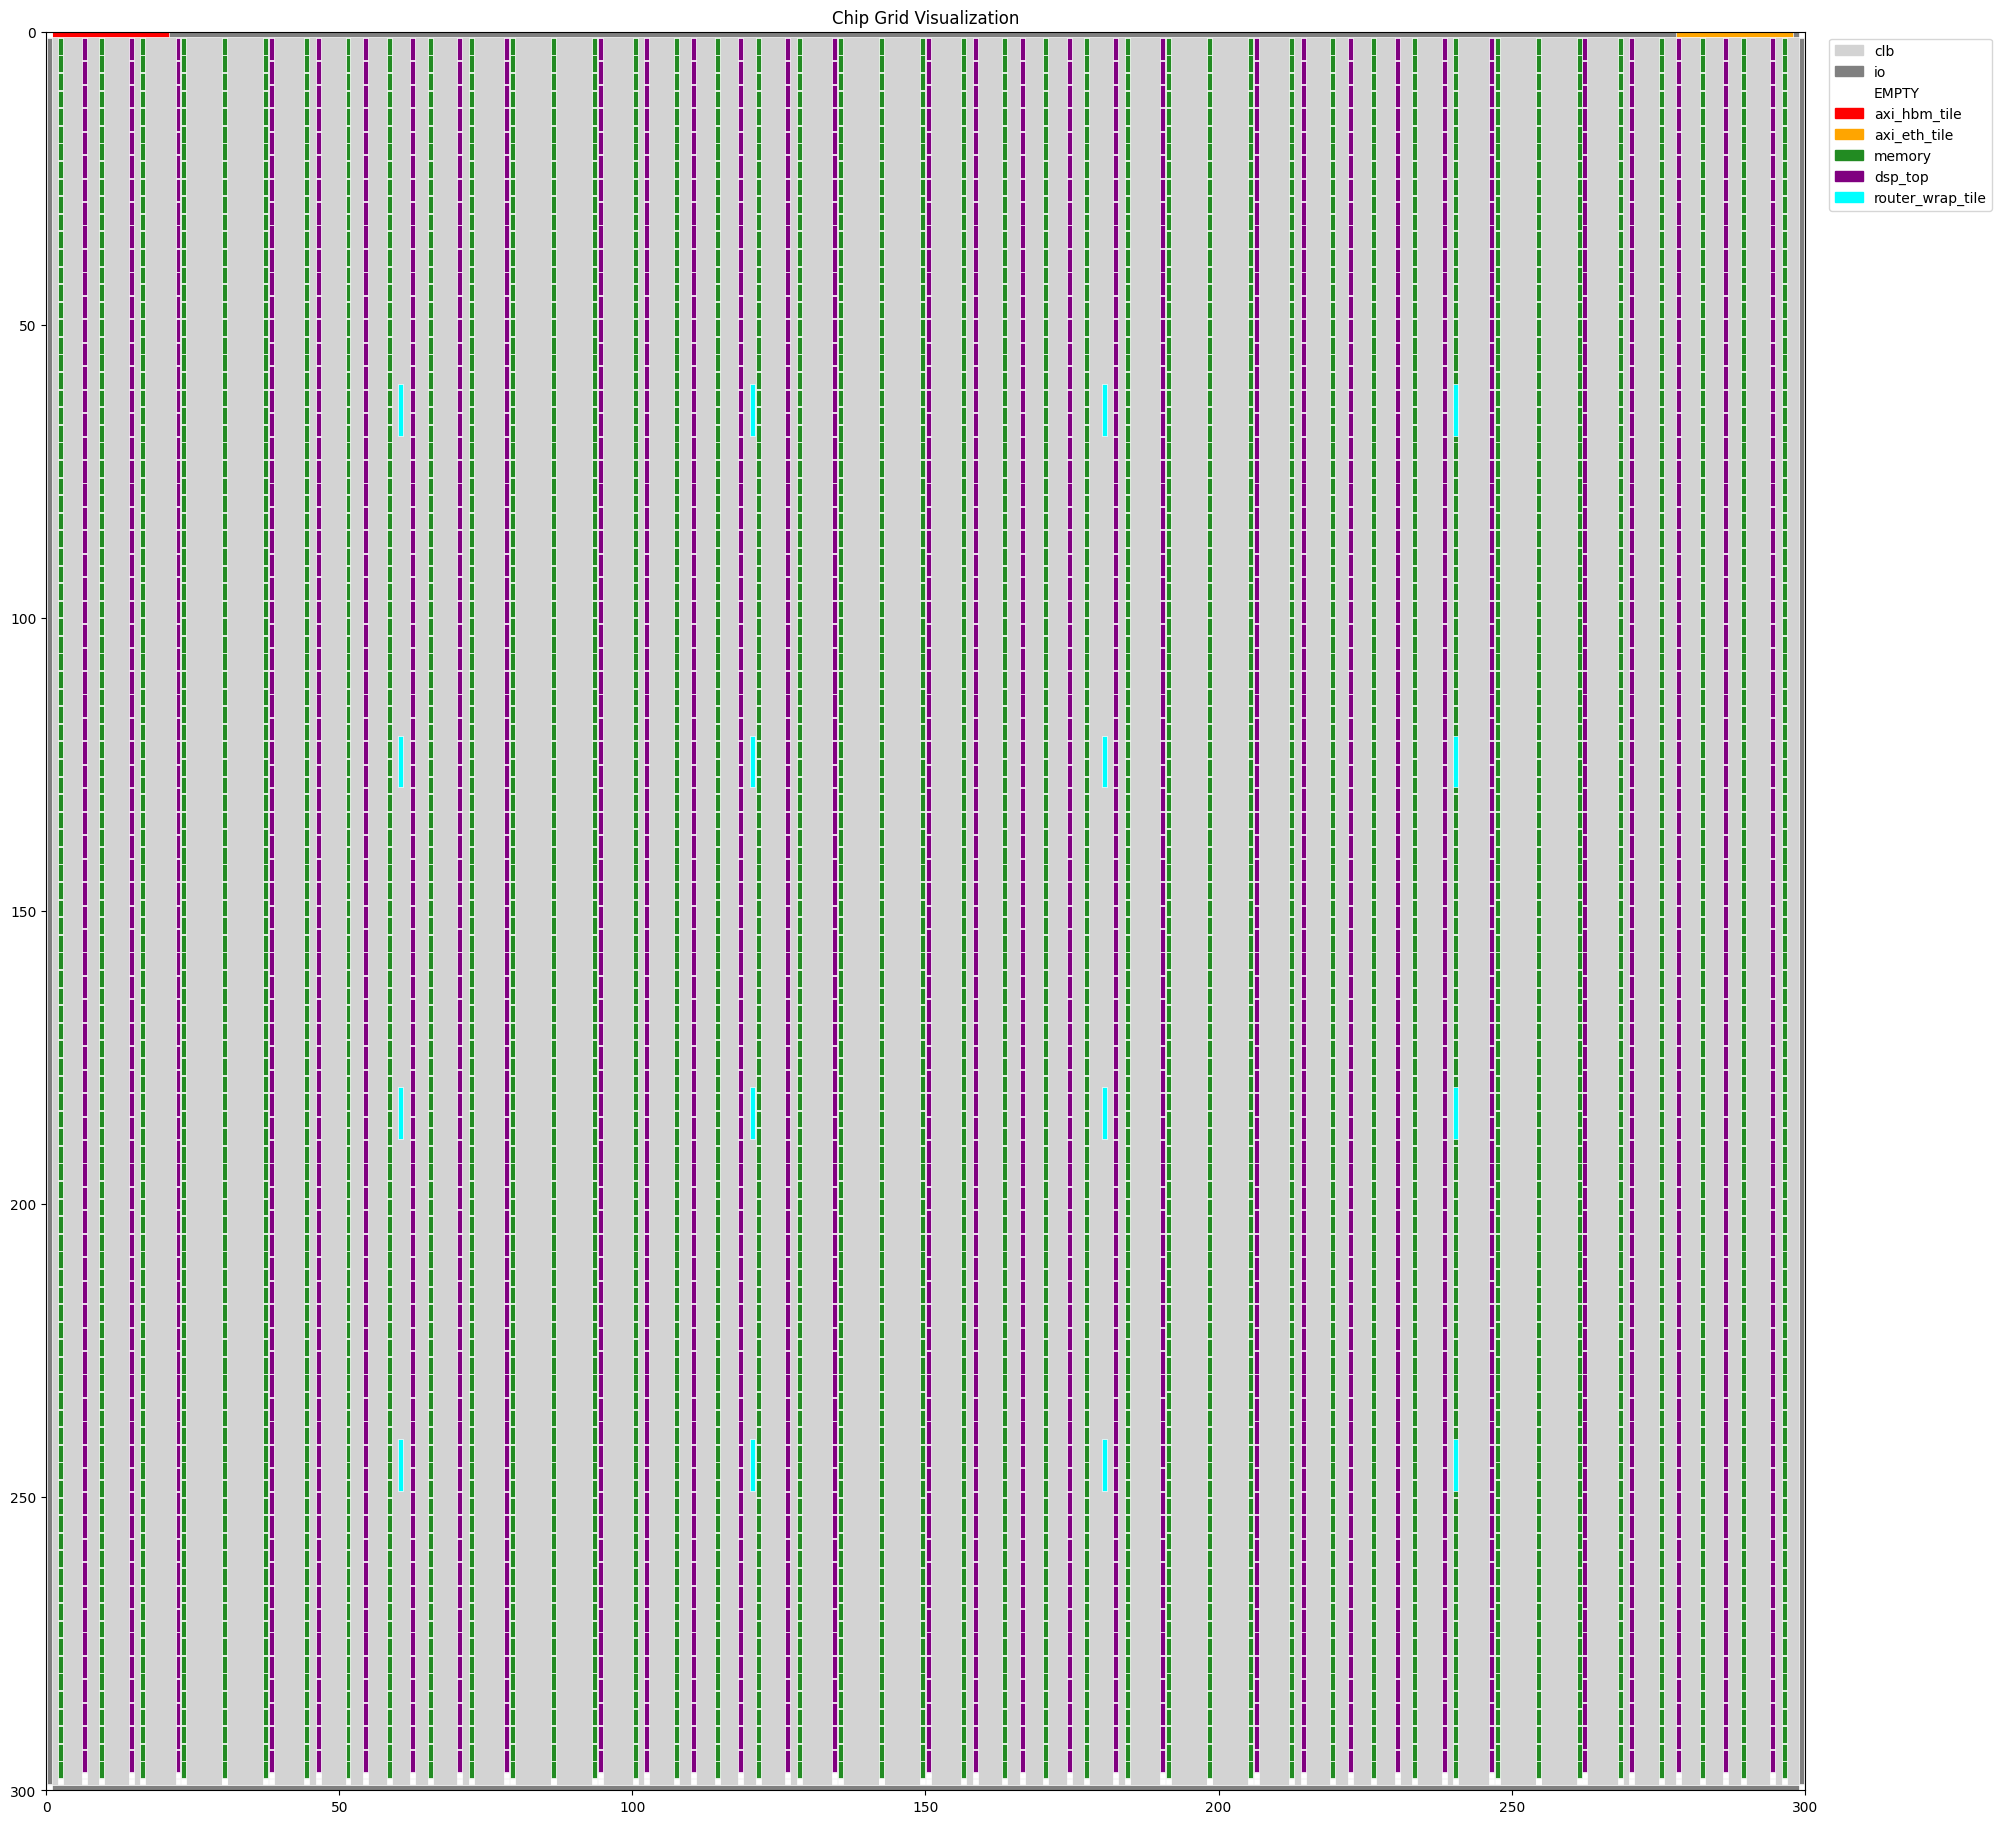

In [2]:
# %%
# This cell visualizes the chip layout as a grid of distinct tiles with visible gaps,
# allowing for clear viewing when zoomed in.

import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Input Data ---
# 1. Tile dimensions.
tile_dims = {
    "router_wrap_tile": {"height": 9, "width": 1},
    "axi_eth_tile": {"height": 1, "width": 20},
    "axi_hbm_tile": {"height": 1, "width": 20},
    "dsp_top": {"height": 4, "width": 1},
    "memory": {"height": 3, "width": 1},
    "io": {"height": 1, "width": 1},
    "clb": {"height": 1, "width": 1},
    "EMPTY": {"height": 1, "width": 1}
}

# 2. The layout definition XML.
xml_data = """
<fixed_layout name="large" width="300" height="300">
    <perimeter type="io" priority="100"/>
    <corners type="EMPTY" priority="110"/>
    <single type="axi_hbm_tile" x="1" y="0" priority="105"/>
    <single type="axi_eth_tile" x="278" y="0" priority="105"/>
    <fill type="clb" priority="10"/>
    <col type="memory" startx="2" starty="1" repeatx="7" priority="30"/>
    <col type="EMPTY"  startx="2"  starty="1" repeatx="7" priority="29"/>
    <col type="dsp_top" startx="6" starty="1" repeatx="8" priority="20"/>
    <col type="EMPTY"   startx="6" starty="1" repeatx="8" priority="19"/>
    <single type="router_wrap_tile" x="W/5" y="H/5" priority="50"/>
    <single type="router_wrap_tile" x="W/5" y="2*H/5" priority="50"/>
    <single type="router_wrap_tile" x="W/5" y="3*H/5" priority="50"/>
    <single type="router_wrap_tile" x="W/5" y="4*H/5" priority="50"/>
    <single type="router_wrap_tile" x="2*W/5" y="H/5" priority="50"/>
    <single type="router_wrap_tile" x="2*W/5" y="2*H/5" priority="50"/>
    <single type="router_wrap_tile" x="2*W/5" y="3*H/5" priority="50"/>
    <single type="router_wrap_tile" x="2*W/5" y="4*H/5" priority="50"/>
    <single type="router_wrap_tile" x="3*W/5" y="H/5" priority="50"/>
    <single type="router_wrap_tile" x="3*W/5" y="2*H/5" priority="50"/>
    <single type="router_wrap_tile" x="3*W/5" y="3*H/5" priority="50"/>
    <single type="router_wrap_tile" x="3*W/5" y="4*H/5" priority="50"/>
    <single type="router_wrap_tile" x="4*W/5" y="H/5" priority="50"/>
    <single type="router_wrap_tile" x="4*W/5" y="2*H/5" priority="50"/>
    <single type="router_wrap_tile" x="4*W/5" y="3*H/5" priority="50"/>
    <single type="router_wrap_tile" x="4*W/5" y="4*H/5" priority="50"/>
</fixed_layout>
"""

# --- Configuration ---
type_colors = {
    'clb': '#D3D3D3', # lightgrey
    'io': '#808080', # grey
    'EMPTY': '#FFFFFF', # white
    'axi_hbm_tile': '#FF0000', # red
    'axi_eth_tile': '#FFA500', # orange
    'memory': '#228B22', # forestgreen
    'dsp_top': '#800080', # purple
    'router_wrap_tile': '#00FFFF' # cyan
}
GAP = 0.15 # The space between tiles

# --- Main Logic ---
def visualize_as_grid(xml_string, dimensions, colors_map):
    """Parses the XML and draws each tile as a gapped rectangle."""
    root = ET.fromstring(xml_string)
    W = int(root.attrib['width'])
    H = int(root.attrib['height'])

    # 1. Setup the plot
    fig, ax = plt.subplots(figsize=(20, 20))
    ax.set_facecolor('#F0F0F0') # Set a background color for the plot area
    
    # 2. Sort elements by priority (lower priority drawn first)
    elements = sorted(root, key=lambda x: int(x.attrib['priority']))

    # 3. Draw each element as a rectangle
    for elem in elements:
        elem_type = elem.attrib['type']
        color = colors_map.get(elem_type, 'black') # Default to black if color not found
        dims = dimensions.get(elem_type, {'height': 1, 'width': 1})
        
        def draw_rect(x, y, w, h, c):
            # The rectangle is made slightly smaller to create the gap
            rect = mpatches.Rectangle(
                (x + GAP / 2, y + GAP / 2), # Bottom-left corner
                w - GAP,                    # Width
                h - GAP,                    # Height
                facecolor=c,
                edgecolor='white' if GAP > 0 else 'none',
                linewidth=0.5
            )
            ax.add_patch(rect)

        if elem.tag == 'fill':
            draw_rect(0, 0, W, H, color)
        
        elif elem.tag == 'perimeter':
            draw_rect(0, 0, W, 1, color)         # Bottom
            draw_rect(0, H-1, W, 1, color)       # Top
            draw_rect(0, 1, 1, H-2, color)       # Left
            draw_rect(W-1, 1, 1, H-2, color)     # Right
            
        elif elem.tag == 'corners':
            w, h = dims['width'], dims['height']
            draw_rect(0, 0, w, h, color)
            draw_rect(W-w, 0, w, h, color)
            draw_rect(0, H-h, w, h, color)
            draw_rect(W-w, H-h, w, h, color)
            
        elif elem.tag == 'single':
            w, h = dims['width'], dims['height']
            x = int(eval(elem.attrib['x'], {"W": W}))
            y = int(eval(elem.attrib['y'], {"H": H}))
            draw_rect(x, y, w, h, color)
            
        elif elem.tag == 'col':
            startx = int(elem.attrib['startx'])
            starty = int(elem.attrib['starty'])
            w, h = dims['width'], dims['height']
            
            if 'repeatx' in elem.attrib:
                pitch = int(elem.attrib['repeatx'])
                k = 0
                while True:
                    x = startx + k * pitch
                    if x >= W: break
                    for y_pos in range(starty, H - starty, h):
                        if y_pos + h <= H - starty:
                            draw_rect(x, y_pos, w, h, color)
                    k += 1
            else: # Single column
                x = startx
                if x < W:
                    for y_pos in range(starty, H - starty, h):
                        if y_pos + h <= H - starty:
                            draw_rect(x, y_pos, w, h, color)

    # 4. Final plot setup
    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal', adjustable='box')
    plt.gca().invert_yaxis() # Put (0,0) in the top-left corner
    
    # Create legend
    patches = [mpatches.Patch(color=c, label=l) for l, c in colors_map.items()]
    plt.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left')
    
    plt.title('Chip Grid Visualization')
    plt.tight_layout()
    plt.show()

# --- Execution ---
visualize_as_grid(xml_data, tile_dims, type_colors)

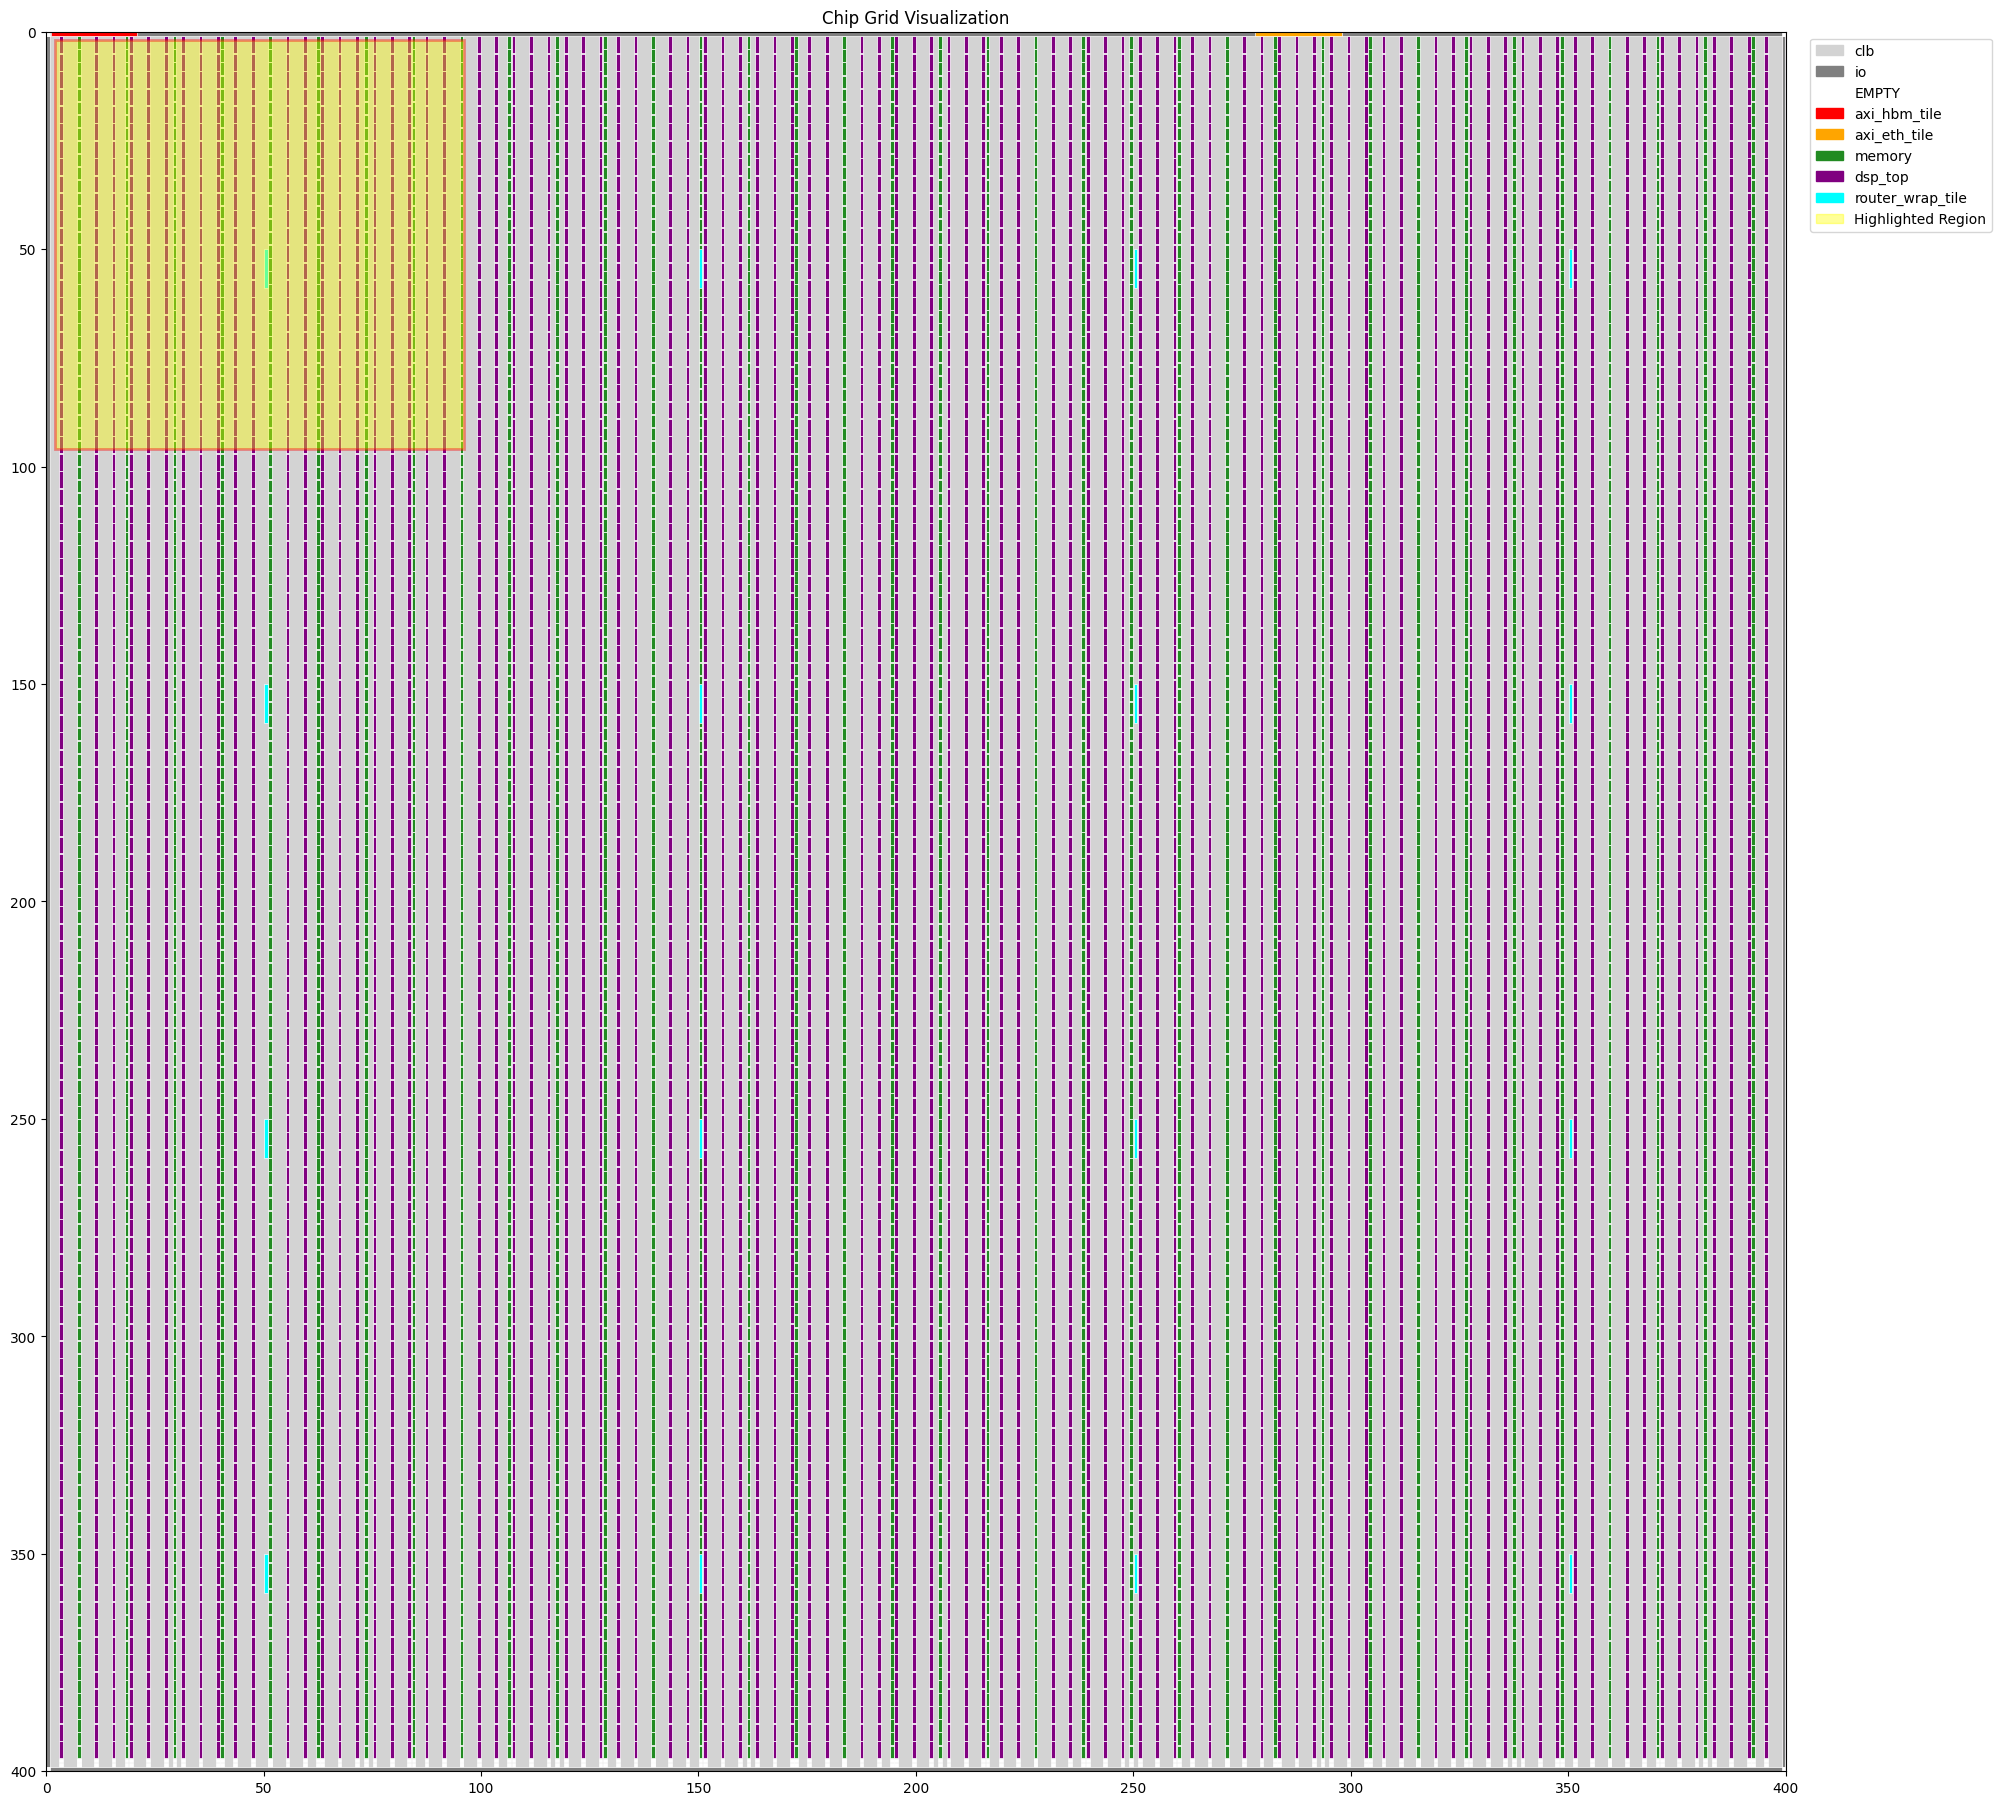

In [59]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Data and Configuration (from previous examples) ---
tile_dims = {
    "router_wrap_tile": {"height": 9, "width": 1}, "axi_eth_tile": {"height": 1, "width": 20},
    "axi_hbm_tile": {"height": 1, "width": 20}, "dsp_top": {"height": 4, "width": 1},
    "memory": {"height": 3, "width": 1}, "io": {"height": 1, "width": 1},
    "clb": {"height": 1, "width": 1}, "EMPTY": {"height": 1, "width": 1}
}
xml_data = """
<fixed_layout name="large" width="400" height="400">
    <perimeter type="io" priority="100"/><corners type="EMPTY" priority="110"/>
    <single type="axi_hbm_tile" x="1" y="0" priority="105"/><single type="axi_eth_tile" x="278" y="0" priority="105"/>
    <fill type="clb" priority="10"/>
    
    <col type="memory" startx="7"  starty="1" repeatx="11" priority="30"/>
    <col type="EMPTY"  startx="7"  starty="1" repeatx="11" priority="29"/>
    
    <col type="dsp_top" startx="3" starty="1" repeatx="4" priority="20"/>
    <col type="EMPTY"   startx="3" starty="1" repeatx="4" priority="19"/>

    <single type="router_wrap_tile" x="W/8" y="H/8"   priority="50"/>
    <single type="router_wrap_tile" x="W/8" y="3*H/8" priority="50"/>
    <single type="router_wrap_tile" x="W/8" y="5*H/8" priority="50"/>
    <single type="router_wrap_tile" x="W/8" y="7*H/8" priority="50"/>
    
    <single type="router_wrap_tile" x="3*W/8" y="H/8"   priority="50"/>
    <single type="router_wrap_tile" x="3*W/8" y="3*H/8" priority="50"/>
    <single type="router_wrap_tile" x="3*W/8" y="5*H/8" priority="50"/>
    <single type="router_wrap_tile" x="3*W/8" y="7*H/8" priority="50"/>
    
    <single type="router_wrap_tile" x="5*W/8" y="H/8"   priority="50"/>
    <single type="router_wrap_tile" x="5*W/8" y="3*H/8" priority="50"/>
    <single type="router_wrap_tile" x="5*W/8" y="5*H/8" priority="50"/>
    <single type="router_wrap_tile" x="5*W/8" y="7*H/8" priority="50"/>
    
    <single type="router_wrap_tile" x="7*W/8" y="H/8"   priority="50"/>
    <single type="router_wrap_tile" x="7*W/8" y="3*H/8" priority="50"/>
    <single type="router_wrap_tile" x="7*W/8" y="5*H/8" priority="50"/>
    <single type="router_wrap_tile" x="7*W/8" y="7*H/8" priority="50"/>
</fixed_layout>
"""
type_colors = {
    'clb': '#D3D3D3', 'io': '#808080', 'EMPTY': '#FFFFFF', 'axi_hbm_tile': '#FF0000',
    'axi_eth_tile': '#FFA500', 'memory': '#228B22', 'dsp_top': '#800080', 'router_wrap_tile': '#00FFFF'
}
GAP = 0.15

# --- Updated Visualization Function ---
def visualize_as_grid(xml_string, dimensions, colors_map, highlight_region=None):
    """
    Parses the XML, draws each tile as a gapped rectangle,
    and overlays a given rectangular region.
    """
    root = ET.fromstring(xml_string)
    W = int(root.attrib['width'])
    H = int(root.attrib['height'])

    fig, ax = plt.subplots(figsize=(20, 20))
    ax.set_facecolor('#F0F0F0')
    elements = sorted(root, key=lambda x: int(x.attrib['priority']))

    # Draw each tile as a rectangle
    for elem in elements:
        # ... (code for drawing individual tiles remains the same as previous examples) ...
        elem_type = elem.attrib['type']
        color = colors_map.get(elem_type, 'black')
        dims = dimensions.get(elem_type, {'height': 1, 'width': 1})
        
        def draw_rect(x, y, w, h, c):
            rect = mpatches.Rectangle((x + GAP / 2, y + GAP / 2), w - GAP, h - GAP,
                                      facecolor=c, edgecolor='white' if GAP > 0 else 'none', linewidth=0.5)
            ax.add_patch(rect)

        if elem.tag == 'fill':
            draw_rect(0, 0, W, H, color)
        elif elem.tag == 'perimeter':
            draw_rect(0, 0, W, 1, color); draw_rect(0, H - 1, W, 1, color)
            draw_rect(0, 1, 1, H - 2, color); draw_rect(W - 1, 1, 1, H - 2, color)
        elif elem.tag == 'corners':
            w, h = dims['width'], dims['height']
            draw_rect(0, 0, w, h, color); draw_rect(W - w, 0, w, h, color)
            draw_rect(0, H - h, w, h, color); draw_rect(W - w, H - h, w, h, color)
        elif elem.tag == 'single':
            w, h = dims['width'], dims['height']
            x = int(eval(elem.attrib['x'], {"W": W})); y = int(eval(elem.attrib['y'], {"H": H}))
            draw_rect(x, y, w, h, color)
        elif elem.tag == 'col':
            startx = int(elem.attrib['startx']); starty = int(elem.attrib['starty'])
            w, h = dims['width'], dims['height']
            if 'repeatx' in elem.attrib:
                pitch = int(elem.attrib['repeatx']); k = 0
                while True:
                    x = startx + k * pitch
                    if x >= W: break
                    for y_pos in range(starty, H - starty, h):
                        if y_pos + h <= H - starty: draw_rect(x, y_pos, w, h, color)
                    k += 1
            else:
                x = startx
                if x < W:
                    for y_pos in range(starty, H - starty, h):
                        if y_pos + h <= H - starty: draw_rect(x, y_pos, w, h, color)

    # --- NEW: Draw the highlighted rectangular region ---
    if highlight_region:
        x1, y1, x2, y2 = highlight_region
        width = x2 - x1 + 1
        height = y2 - y1 + 1
        
        # Create a semi-transparent rectangle patch
        overlay = mpatches.Rectangle(
            (x1, y1), width, height,
            facecolor='yellow',
            alpha=0.4,
            edgecolor='red',
            linewidth=2,
            label='Highlighted Region'  # Label for the legend
        )
        ax.add_patch(overlay)

    # Final plot setup
    ax.set_xlim(0, W); ax.set_ylim(0, H)
    ax.set_aspect('equal', adjustable='box')
    plt.gca().invert_yaxis()
    
    patches = [mpatches.Patch(color=c, label=l) for l, c in colors_map.items()]
    if highlight_region:
        patches.append(mpatches.Patch(color='yellow', alpha=0.4, label='Highlighted Region'))
    plt.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left')
    
    plt.title('Chip Grid Visualization')
    plt.tight_layout()
    plt.show()


# Define the coordinates of the rectangle to display
# solution_rectangle = (3, 3, 75, 75)
solution_rectangle = (2, 2, 95, 95)


# Call the visualization function with the highlight_region argument
visualize_as_grid(xml_data, tile_dims, type_colors, highlight_region=solution_rectangle)

In [25]:
def get_all_blocks(xml_string, dimensions):
    """
    Parses the XML and generates a master list of every block instance.
    This list is used as the basis for counting.
    """
    root = ET.fromstring(xml_string)
    W = int(root.attrib['width'])
    H = int(root.attrib['height'])
    
    # We use a dictionary to handle priorities: higher priority blocks overwrite lower ones.
    # The key is the (x,y) coordinate, the value is the block info.
    grid_of_blocks = {}

    elements = sorted(root, key=lambda x: int(x.attrib['priority']))
    
    for elem in elements:
        elem_type = elem.attrib['type']
        dims = dimensions.get(elem_type, {'height': 1, 'width': 1})
        w, h = dims['width'], dims['height']

        if elem.tag == 'fill':
            for y in range(H):
                for x in range(W):
                    grid_of_blocks[(x, y)] = (elem_type, x, y, 1, 1) # Fill is 1x1 cells
        
        elif elem.tag == 'perimeter':
            # This logic draws 1x1 'io' blocks along the border
            for x in range(W):
                grid_of_blocks[(x, 0)] = (elem_type, x, 0, 1, 1)
                grid_of_blocks[(x, H - 1)] = (elem_type, x, H - 1, 1, 1)
            for y in range(1, H - 1):
                grid_of_blocks[(0, y)] = (elem_type, 0, y, 1, 1)
                grid_of_blocks[(W - 1, y)] = (elem_type, W - 1, y, 1, 1)
                
        elif elem.tag == 'corners':
            # Mark all positions occupied by each corner
            for corner_x, corner_y in [(0, 0), (W - w, 0), (0, H - h), (W - w, H - h)]:
                for dy in range(h):
                    for dx in range(w):
                        grid_of_blocks[(corner_x + dx, corner_y + dy)] = (elem_type, corner_x, corner_y, w, h)
            
        elif elem.tag == 'single':
            x = int(eval(elem.attrib['x'], {"W": W, "H": H}))
            y = int(eval(elem.attrib['y'], {"H": H, "W": W}))
            # Mark all positions occupied by this block
            for dy in range(h):
                for dx in range(w):
                    grid_of_blocks[(x + dx, y + dy)] = (elem_type, x, y, w, h)
            
        elif elem.tag == 'col':
            startx = int(elem.attrib['startx'])
            starty = int(elem.attrib['starty'])
            
            if 'repeatx' in elem.attrib:
                pitch = int(elem.attrib['repeatx'])
                k = 0
                while True:
                    x = startx + k * pitch
                    if x >= W: break
                    for y_pos in range(starty, H - starty, h):
                        if y_pos + h <= H - starty:
                            # Mark all positions occupied by this block
                            for dy in range(h):
                                for dx in range(w):
                                    grid_of_blocks[(x + dx, y_pos + dy)] = (elem_type, x, y_pos, w, h)
                    k += 1
            else: # Single column
                x = startx
                if x < W:
                    for y_pos in range(starty, H - starty, h):
                        if y_pos + h <= H - starty:
                            # Mark all positions occupied by this block
                            for dy in range(h):
                                for dx in range(w):
                                    grid_of_blocks[(x + dx, y_pos + dy)] = (elem_type, x, y_pos, w, h)
                            
    # Convert to list of unique blocks based on origin coordinates
    unique_blocks = {}
    for block_type, x, y, w, h in grid_of_blocks.values():
        unique_blocks[(block_type, x, y)] = (block_type, x, y, w, h)
    
    return list(unique_blocks.values())

In [62]:
from collections import defaultdict 

# def get_all_blocks(xml_string, dimensions):
#     """
#     Parses the XML and generates a master list of every block instance.
#     This list is used as the basis for counting.
#     """
#     root = ET.fromstring(xml_string)
#     W = int(root.attrib['width'])
#     H = int(root.attrib['height'])
    
#     # We use a dictionary to handle priorities: higher priority blocks overwrite lower ones.
#     # The key is the (x,y) coordinate, the value is the block info.
#     grid_of_blocks = {}

#     elements = sorted(root, key=lambda x: int(x.attrib['priority']))
    
#     for elem in elements:
#         elem_type = elem.attrib['type']
#         dims = dimensions.get(elem_type, {'height': 1, 'width': 1})
#         w, h = dims['width'], dims['height']

#         if elem.tag == 'fill':
#             for y in range(H):
#                 for x in range(W):
#                     grid_of_blocks[(x, y)] = (elem_type, x, y, 1, 1) # Fill is 1x1 cells
        
#         elif elem.tag == 'perimeter':
#             # This logic draws 1x1 'io' blocks along the border
#             for x in range(W):
#                 grid_of_blocks[(x, 0)] = (elem_type, x, 0, 1, 1)
#                 grid_of_blocks[(x, H - 1)] = (elem_type, x, H - 1, 1, 1)
#             for y in range(1, H - 1):
#                 grid_of_blocks[(0, y)] = (elem_type, 0, y, 1, 1)
#                 grid_of_blocks[(W - 1, y)] = (elem_type, W - 1, y, 1, 1)
                
#         elif elem.tag == 'corners':
#             grid_of_blocks[(0, 0)] = (elem_type, 0, 0, w, h)
#             grid_of_blocks[(W - w, 0)] = (elem_type, W - w, 0, w, h)
#             grid_of_blocks[(0, H - h)] = (elem_type, 0, H - h, w, h)
#             grid_of_blocks[(W - w, H - h)] = (elem_type, W - w, H - h, w, h)
            
#         elif elem.tag == 'single':
#             x = int(eval(elem.attrib['x'], {"W": W, "H": H}))
#             y = int(eval(elem.attrib['y'], {"H": H, "W": W}))
#             grid_of_blocks[(x, y)] = (elem_type, x, y, w, h)
            
#         elif elem.tag == 'col':
#             startx = int(elem.attrib['startx'])
#             starty = int(elem.attrib['starty'])
            
#             if 'repeatx' in elem.attrib:
#                 pitch = int(elem.attrib['repeatx'])
#                 k = 0
#                 while True:
#                     x = startx + k * pitch
#                     if x >= W: break
#                     for y_pos in range(starty, H - starty, h):
#                         if y_pos + h <= H - starty:
#                             grid_of_blocks[(x, y_pos)] = (elem_type, x, y_pos, w, h)
#                     k += 1
#             else: # Single column
#                 x = startx
#                 if x < W:
#                     for y_pos in range(starty, H - starty, h):
#                         if y_pos + h <= H - starty:
#                             grid_of_blocks[(x, y_pos)] = (elem_type, x, y_pos, w, h)
                            
#     return list(grid_of_blocks.values())


def count_contained_blocks(all_blocks, region):
    """
    Counts blocks from a master list that are fully contained within a region.
    
    Args:
        all_blocks (list): A list of block tuples (type, x, y, width, height).
        region (tuple): A tuple defining the rectangle (x1, y1, x2, y2).
        
    Returns:
        A dictionary with the counts of contained blocks.
    """
    x1, y1, x2, y2 = region
    block_counts = defaultdict(int)

    for block_type, b_x, b_y, b_w, b_h in all_blocks:
        # Check if the block's top-left (b_x, b_y) and bottom-right
        # (b_x + b_w - 1, b_y + b_h - 1) corners are within the region.
        is_contained = (
            b_x >= x1 and
            b_y >= y1 and
            (b_x + b_w - 1) <= x2 and
            (b_y + b_h - 1) <= y2
        )
        
        if is_contained:
            block_counts[block_type] += 1
            
    return dict(block_counts)

# --- Example Usage ---

# 1. Generate the master list of all blocks from the layout
print("Generating master list of all blocks...")
master_block_list = get_all_blocks(xml_data, tile_dims)
print(f"Done. Found {len(master_block_list)} total block instances.")

# 2. Define the rectangular region you want to analyze
# Using the optimal region from our previous analysis: (x1, y1, x2, y2)
# regions_to_check = [(5, 5, 95, 95)]
regions_to_check = [(5, 5, 95, 95), (105, 5, 195, 95), (205, 5, 295, 95), (305, 5, 395, 95),
 (5, 105, 95, 195), (105, 105, 195, 195), (205, 105, 295, 195), (305, 105, 395, 195),
 (5, 205, 95, 295), (105, 205, 195, 295), (205, 205, 295, 295), (305, 205, 395, 295),
 (5, 305, 95, 395), (105, 305, 195, 395), (205, 305, 295, 395), (305, 305, 395, 395)]
# regions_to_check = [ (2, 2, 74, 74)		, (77, 2, 149, 74)	, (152, 2, 224, 74)	, (227, 2, 299, 74)	, (2, 77, 74, 149)	, (77, 77, 149, 149)	, (152, 77, 224, 149)	, (227, 77, 299, 149)	, (2, 152, 74, 224), (77, 152, 149, 224), (152, 152, 224, 224), (227, 152, 299, 224), (2, 227, 74, 299), (77, 227, 149, 299), (152, 227, 224, 299), (227, 227, 299, 299) ]


needed_clb = 4975
needed_dsp = 385
needed_memory = 156
needed_router = 1


# 3. Count the blocks fully contained within that region
for region in regions_to_check:
    print(f"\nCounting blocks fully contained within {region}...")
    contained_counts = count_contained_blocks(master_block_list, region)

    # 4. Print the results
    # print("\n--- Results ---")
    for block_type, count in sorted(contained_counts.items()):
        print(f"{block_type:<18}: {count}")

    # check if all needed blocks are present
    if (contained_counts.get('clb', 0) >= needed_clb and
        contained_counts.get('dsp_top', 0) >= needed_dsp and
        contained_counts.get('memory', 0) >= needed_memory and
        contained_counts.get('router_wrap_tile', 0) >= needed_router):
        print("All needed blocks are present.")
    else:
        print("Some needed blocks are missing.")

#   io      : 142
#   clb     : 3395
#   dsp_top : 126
#   memory  : 184
#   router  : 1

Generating master list of all blocks...
Done. Found 123627 total block instances.

Counting blocks fully contained within (5, 5, 95, 95)...
clb               : 5633
dsp_top           : 440
memory            : 261
router_wrap_tile  : 1
All needed blocks are present.

Counting blocks fully contained within (105, 5, 195, 95)...
clb               : 5551
dsp_top           : 462
memory            : 259
router_wrap_tile  : 1
All needed blocks are present.

Counting blocks fully contained within (205, 5, 295, 95)...
clb               : 5542
dsp_top           : 462
memory            : 261
router_wrap_tile  : 1
All needed blocks are present.

Counting blocks fully contained within (305, 5, 395, 95)...
clb               : 5633
dsp_top           : 462
memory            : 232
router_wrap_tile  : 1
All needed blocks are present.

Counting blocks fully contained within (5, 105, 95, 195)...
clb               : 5633
dsp_top           : 440
memory            : 270
router_wrap_tile  : 1
All needed blocks

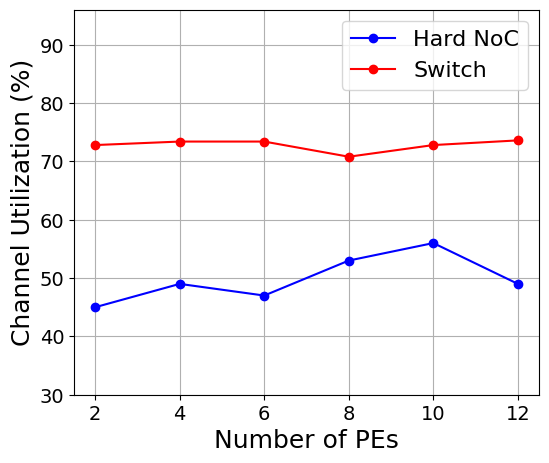

In [1]:
import matplotlib.pyplot as plt

#  HBM ETH 
x = [2, 4, 6, 8, 10, 12]
# hard_wirelength = [1.262e+06,  2.517e+06, 3.825e+06, 5.288e+06, 6.684e+06, 7.989e+06]
hard_wire_util =  [0.45, 0.49, 0.47, 0.53, 0.56, 0.49]
# Convert hard_wire_util to percentage for plotting (use only the first 6 values to match x)
hard_wire_util = [v * 100 for v in hard_wire_util[:6]]
# axi_wirelength = [1.235e+06, 2.452e+06, 3.8e+06, 5.096e+06, 6.461e+06, 7.94e+06]
axi_wire_util  = [0.728, 0.734, 0.734, 0.708, 0.728, 0.736]
axi_wire_util = [v * 100 for v in axi_wire_util[:6]]

plt.figure(figsize=(6, 5))
plt.plot(x, hard_wire_util, marker='o', color='blue', label='Hard NoC')
plt.plot(x, axi_wire_util, marker='o', color='red', label='Switch')
plt.xlabel('Number of PEs', fontsize=18)
plt.ylabel('Channel Utilization (%)', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)

# plt.title('Plot of x vs y_hard and y_axi')
plt.ylim(30, 96)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()

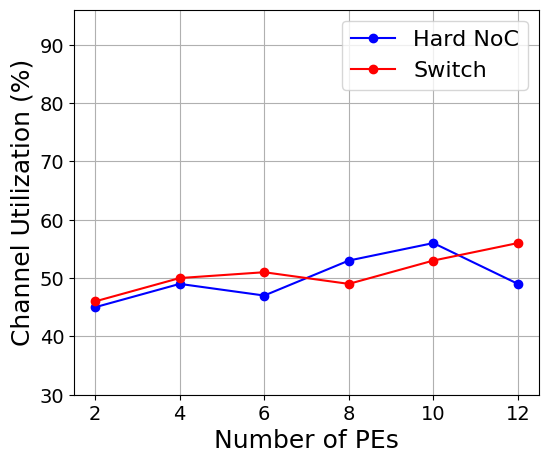

In [2]:
import matplotlib.pyplot as plt

#  Regular switch, no HBM, ETH

x = [2, 4, 6, 8, 10, 12]
# hard_wirelength = [1.262e+06,  2.517e+06, 3.825e+06, 5.288e+06, 6.684e+06, 7.989e+06]
hard_wire_util =  [0.45, 0.49, 0.47, 0.53, 0.56, 0.49]
# Convert hard_wire_util to percentage for plotting (use only the first 6 values to match x)
hard_wire_util = [v * 100 for v in hard_wire_util[:6]]
# axi_wirelength = [1.235e+06, 2.452e+06, 3.8e+06, 5.096e+06, 6.461e+06, 7.94e+06]
# axi_wire_util  = [0.728, 0.734, 0.734, 0.708, 0.728, 0.736]
axi_wire_util  = [0.46, 0.5, 0.51, 0.49, 0.53, 0.56]

axi_wire_util = [v * 100 for v in axi_wire_util[:6]]

plt.figure(figsize=(6, 5))
plt.plot(x, hard_wire_util, marker='o', color='blue', label='Hard NoC')
plt.plot(x, axi_wire_util, marker='o', color='red', label='Switch')
plt.xlabel('Number of PEs', fontsize=18)
plt.ylabel('Channel Utilization (%)', fontsize=18)
# plt.title('Plot of x vs y_hard and y_axi')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.ylim(30, 96)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()

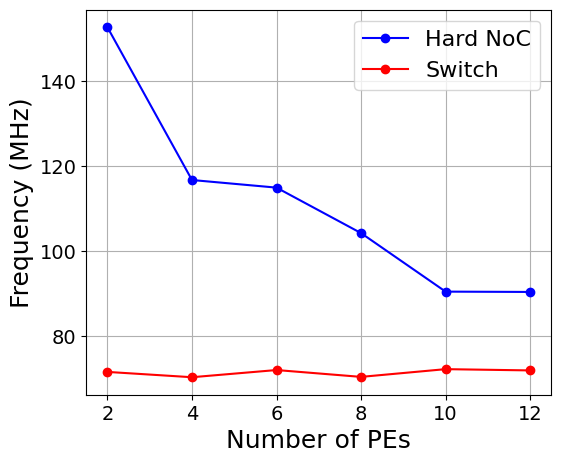

In [3]:
import matplotlib.pyplot as plt

# Frequency data for Hard NoC and AXI-S switch for HBM ETH varient - EXP 1

x = [2, 4, 6, 8, 10, 12]
y_hard = [152.682, 116.732, 114.941, 104.241, 90.47, 90.3946]
y_axi =  [71.58,   70.33,   72.02,   70.41,   72.23, 71.93]

plt.figure(figsize=(6, 5))
plt.plot(x, y_hard, marker='o', color='blue', label='Hard NoC')
plt.plot(x, y_axi, marker='o', color='red', label='Switch')
plt.xlabel('Number of PEs', fontsize=18)
plt.ylabel('Frequency (MHz)', fontsize=18)
# plt.title('Plot of x vs y_hard and y_axi')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.grid(True)
plt.legend(fontsize=16)
plt.show()

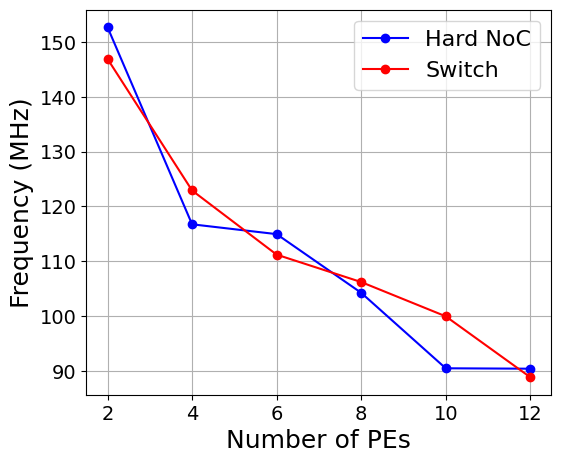

In [4]:
import matplotlib.pyplot as plt

# Frequency data for Hard NoC and AXI-S switch for regular, no HBM, ETH

x = [2, 4, 6, 8, 10, 12]
y_hard = [152.682, 116.732, 114.941, 104.241, 90.47, 90.3946]
#   [71.58,   70.33,   72.02,   70.41,   72.23, 71.93]
y_axi = [146.9, 122.9, 111.2, 106.2, 99.95, 88.84]

plt.figure(figsize=(6, 5))
plt.plot(x, y_hard, marker='o', color='blue', label='Hard NoC')
plt.plot(x, y_axi, marker='o', color='red', label='Switch')
plt.xlabel('Number of PEs', fontsize=18)
plt.ylabel('Frequency (MHz)', fontsize=18)
# plt.title('Plot of x vs y_hard and y_axi')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()

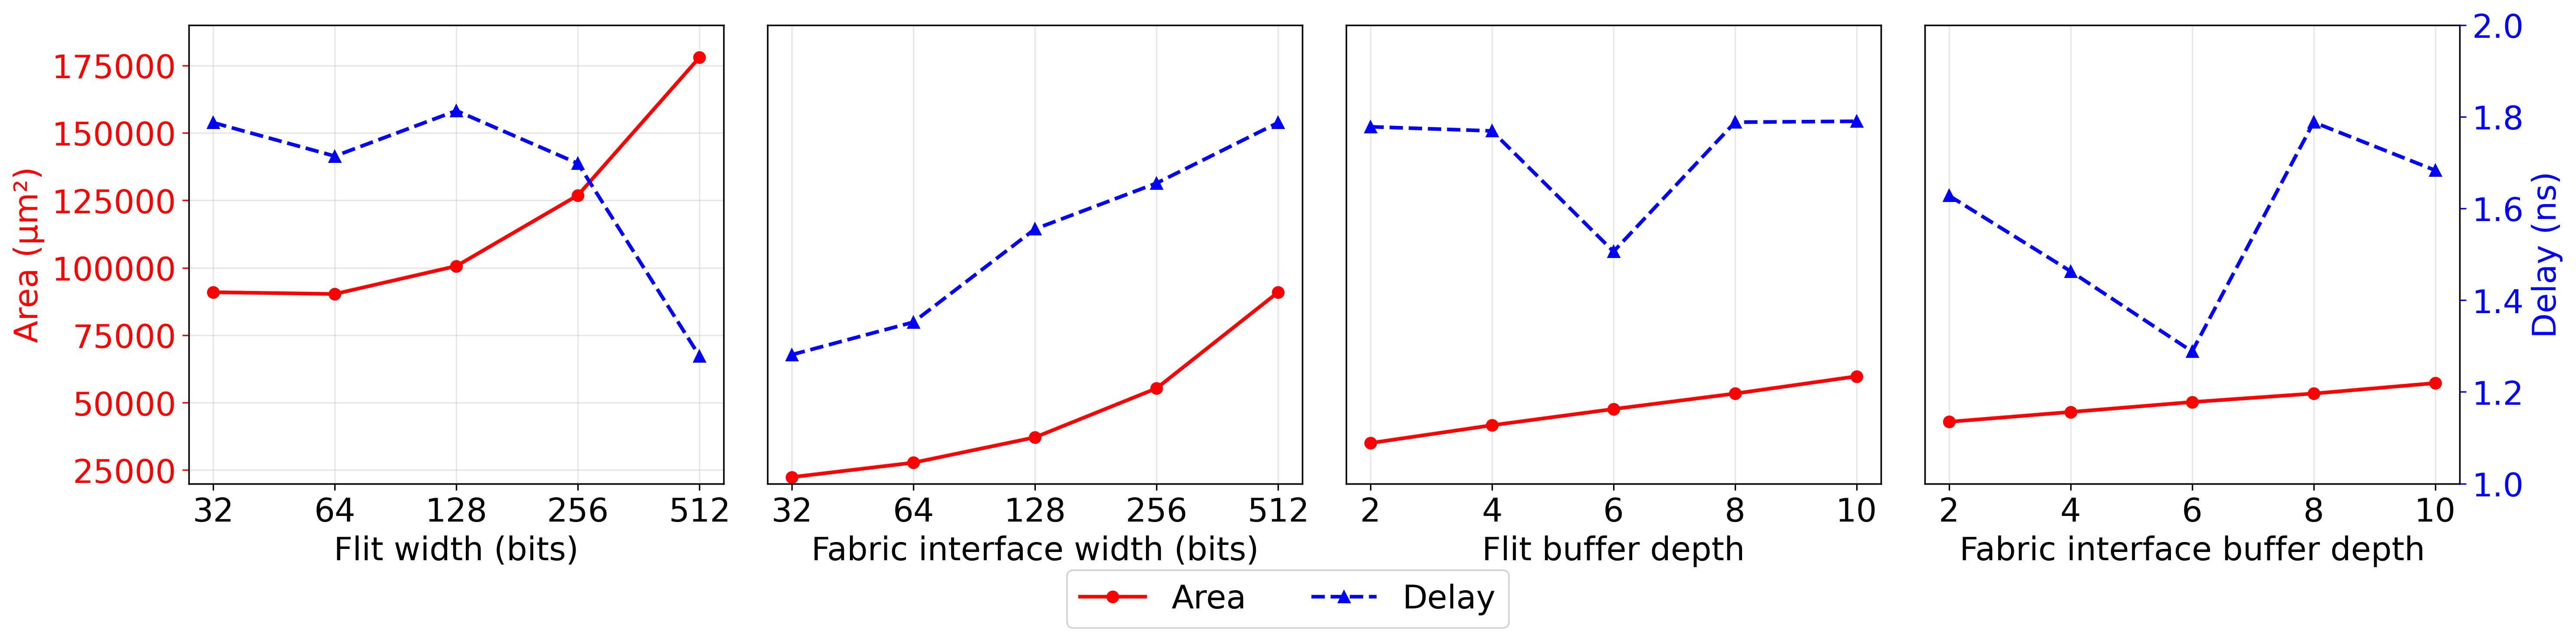

In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Set up the figure with four subplots in a row
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5), dpi=300)

# Common style parameters
area_style = {'color': 'r', 'marker': 'o', 'linestyle': '-', 'linewidth': 2, 'label': 'Area'}
delay_style = {'color': 'b', 'marker': '^', 'linestyle': '--', 'linewidth': 2, 'label': 'Delay'}

depths = [2, 4, 6, 8, 10]

# =============== PLOT 1: FLIT WIDTH IMPACT ===============
flit_widths = [32, 64, 128, 256, 512]
flit_areas = [90932.1, 90281.464, 100634.184, 126885.192, 177986.718]
flit_delays = [1.787, 1.714, 1.813, 1.698, 1.278]

ax1 = axs[0]
ax1_2 = ax1.twinx()

# Plot area on left y-axis
ax1.plot(depths, flit_areas, **area_style)
ax1.set_xlabel('Flit width (bits)', fontsize=18)
ax1.set_xticks(depths)
ax1.set_xticklabels(flit_widths)  # Set x-ticks to flit widths

ax1.set_ylabel('Area (μm²)', color='r', fontsize=18)
ax1.tick_params(axis='y', colors='r')
ax1.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax1_2.plot(depths, flit_delays, **delay_style)

ax1_2.set_ylim(1.0, 2.0)
ax1_2.yaxis.set_ticks([]) 


# ax1.set_title('Flit Width Impact', fontsize=11)
ax1.grid(True, alpha=0.3)

# =============== PLOT 2: INTERFACE WIDTH IMPACT ===============
interface_widths = [32, 64, 128, 256, 512]
interface_areas = [22387.624, 27746.992, 37134.398, 55305.39, 90932.1]
interface_delays = [1.281, 1.352, 1.555, 1.655, 1.787]

ax2 = axs[1]
ax2_2 = ax2.twinx()

# Plot area on left y-axis
ax2.plot(depths, interface_areas, **area_style)
ax2.set_xlabel('Fabric interface width (bits)', fontsize=18)
ax2.set_xticks(depths)
ax2.set_xticklabels(interface_widths)  # Set x-ticks to interface widths 
ax2.yaxis.set_ticks([]) 
ax2.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax2_2.plot(depths, interface_delays, **delay_style)
ax2_2.yaxis.set_ticks([])
ax2_2.set_ylim(1.0, 2.0)

ax2.grid(True, alpha=0.3)

# =============== PLOT 3: FLIT BUFFER DEPTH IMPACT ===============
depths = [2, 4, 6, 8, 10]
flit_buf_areas = [35024.22, 41617.03, 47620.65, 53370.24, 59752.644]
flit_buf_delays = [1.778, 1.769, 1.506, 1.788, 1.79]

ax3 = axs[2]
ax3_2 = ax3.twinx()

# Plot area on left y-axis
ax3.plot(depths, flit_buf_areas, **area_style)
ax3.set_xlabel('Flit buffer depth', fontsize=18)
ax3.yaxis.set_ticks([])
ax3.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax3_2.plot(depths, flit_buf_delays, **delay_style)
ax3_2.yaxis.set_ticks([])
ax3_2.set_ylim(1.0, 2.0)

ax3.grid(True, alpha=0.3)

# =============== PLOT 4: INTERFACE BUFFER DEPTH IMPACT ===============
if_buf_areas = [42894.894, 46535.104, 50220.8, 53370.24, 57248.52]
if_buf_delays = [1.628, 1.463, 1.288, 1.788, 1.683]

ax4 = axs[3]
ax4_2 = ax4.twinx()

# Plot area on left y-axis
ax4.plot(depths, if_buf_areas, **area_style)
ax4.set_xlabel('Fabric interface buffer depth', fontsize=18)
ax4.yaxis.set_ticks([])
ax4.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax4_2.plot(depths, if_buf_delays, **delay_style)
ax4_2.set_ylabel('Delay (ns)', color='b', fontsize=18)
ax4_2.tick_params(axis='y', colors='b')
ax4_2.set_ylim(1.0, 2.0)

ax4.grid(True, alpha=0.3)

# Create a shared legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.03))

plt.tight_layout()

plt.rcParams.update({'font.size': 14})

# # Set specific element font sizes
# plt.rcParams.update({
#     'axes.titlesize': 14,     # Plot titles
#     'axes.labelsize': 18,     # Axis labels
#     'xtick.labelsize': 16,    # X-axis tick labels
#     'ytick.labelsize': 16,    # Y-axis tick labels
#     'legend.fontsize': 16,    # Legend text
# })

plt.subplots_adjust(bottom=0.15)  # Make room for the legend at the bottom
plt.savefig('noc_design_parameters.png', bbox_inches='tight')
plt.show()

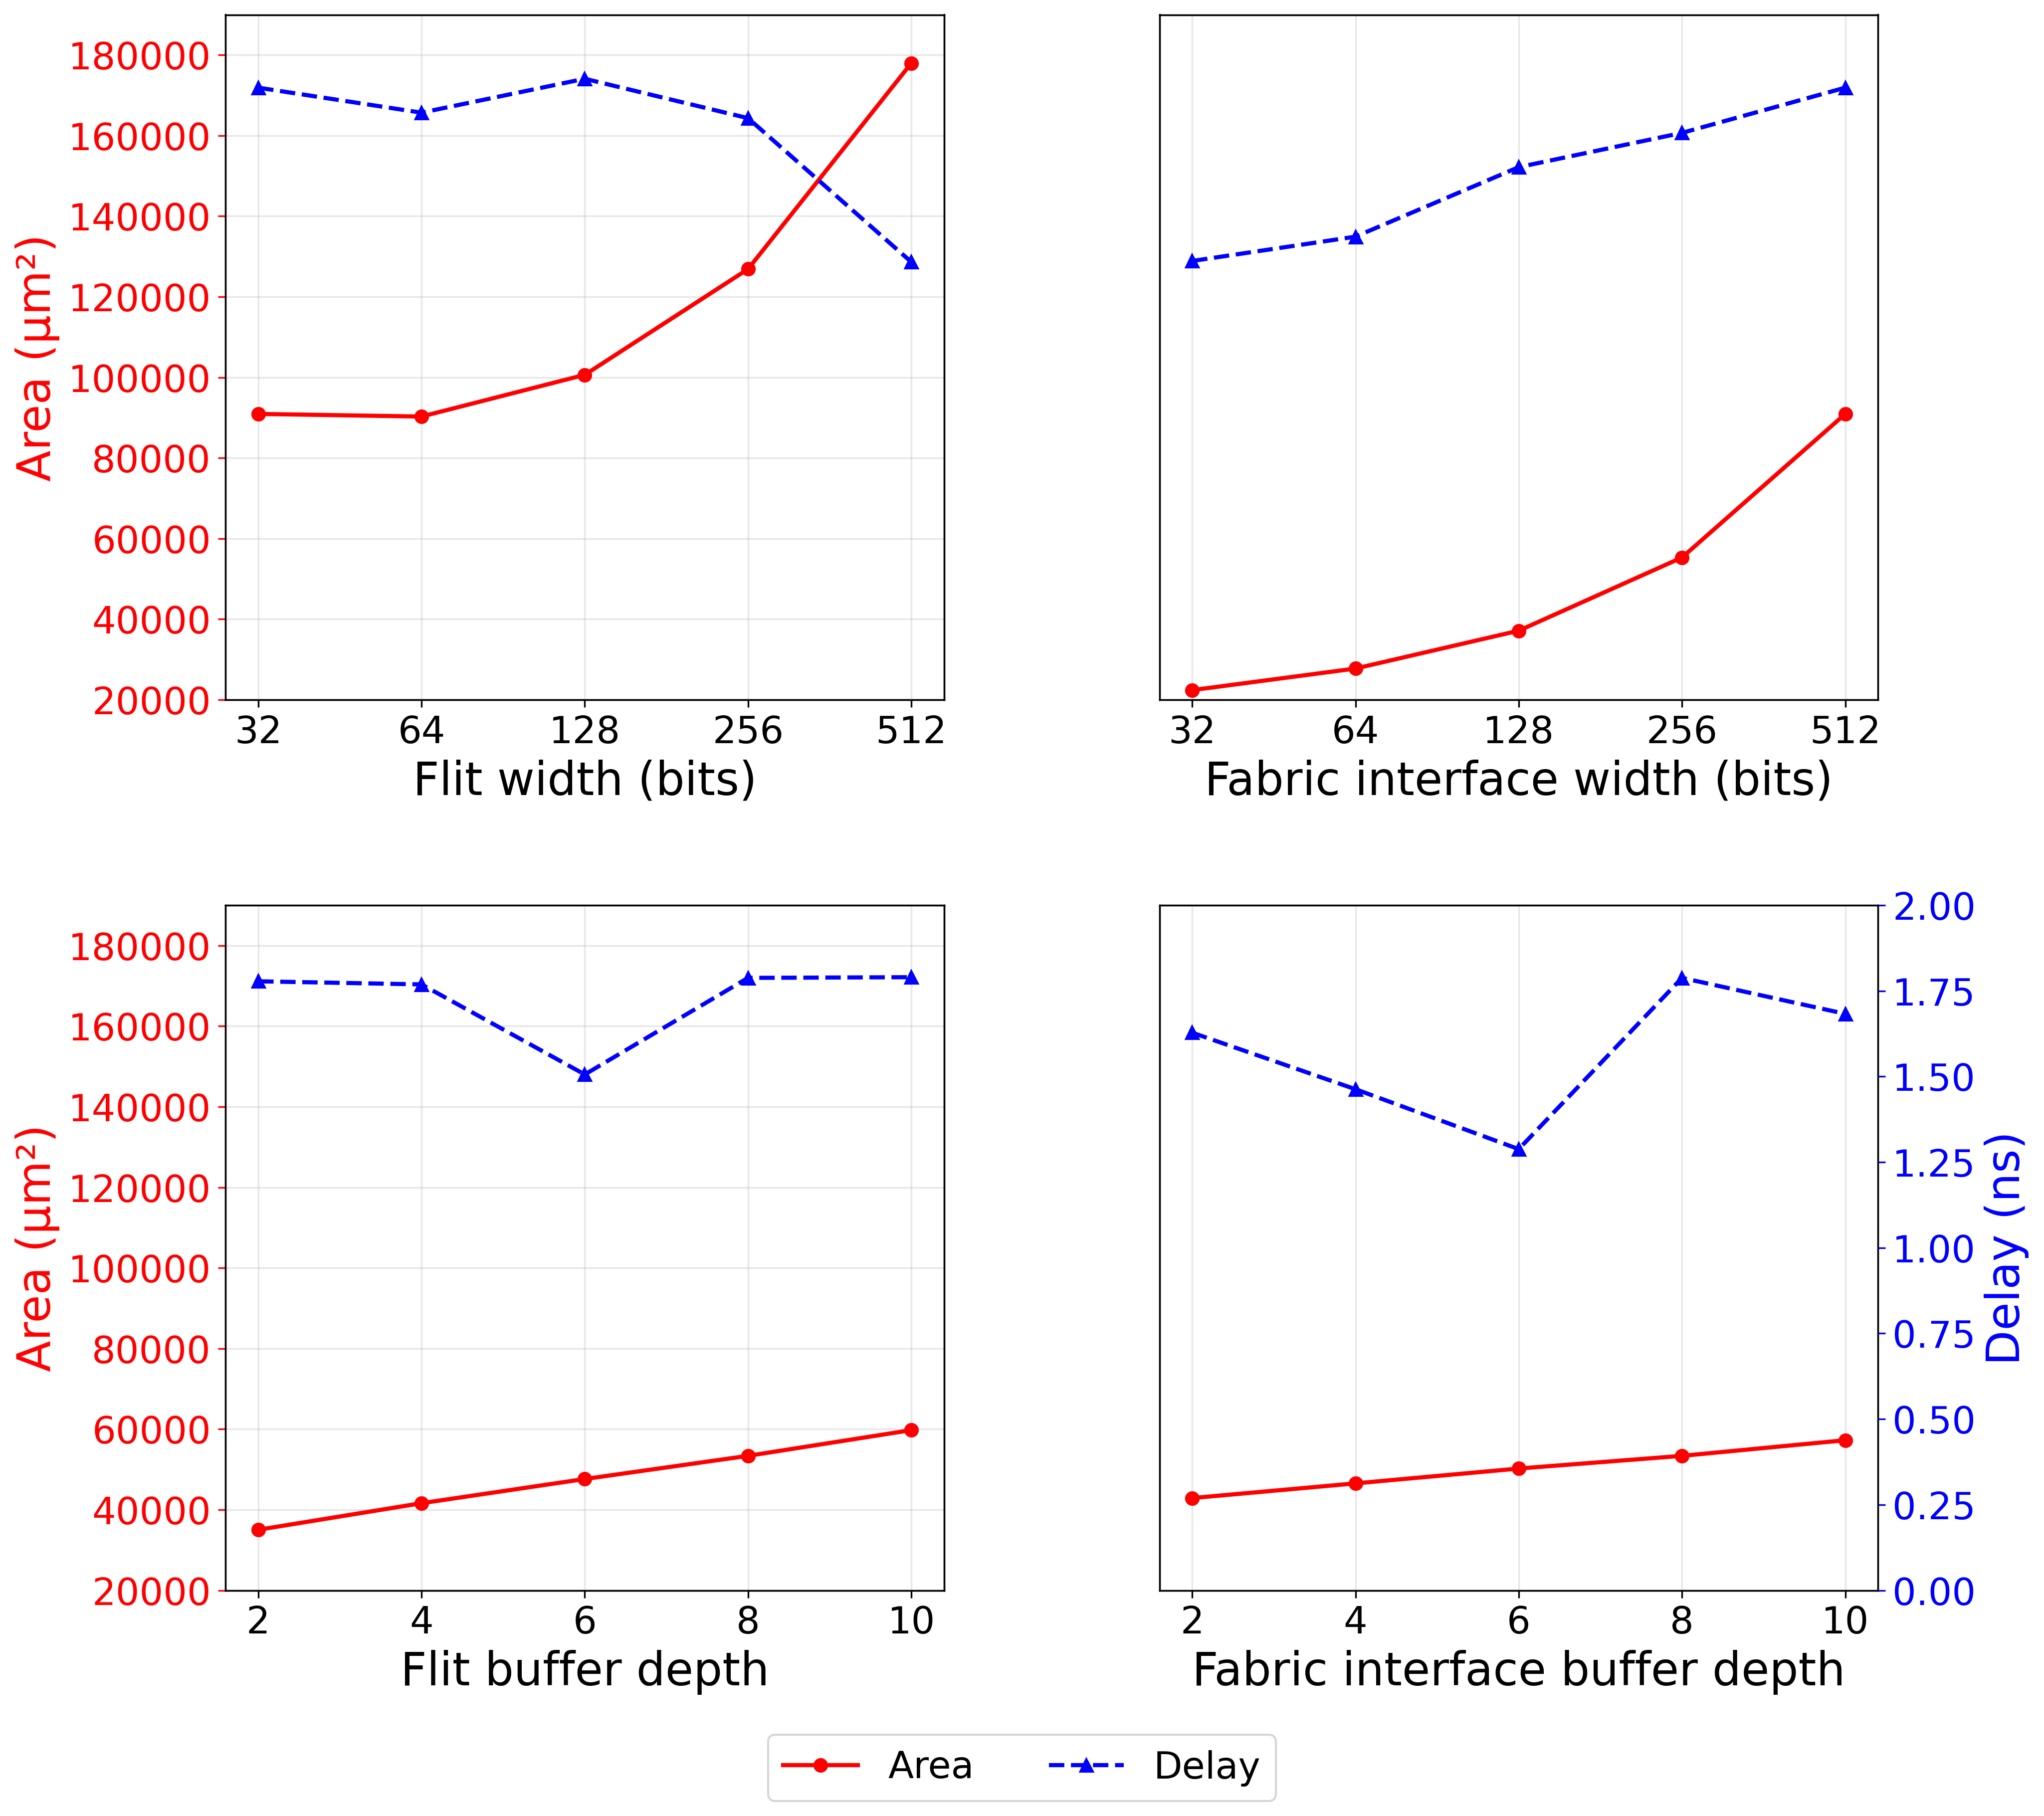

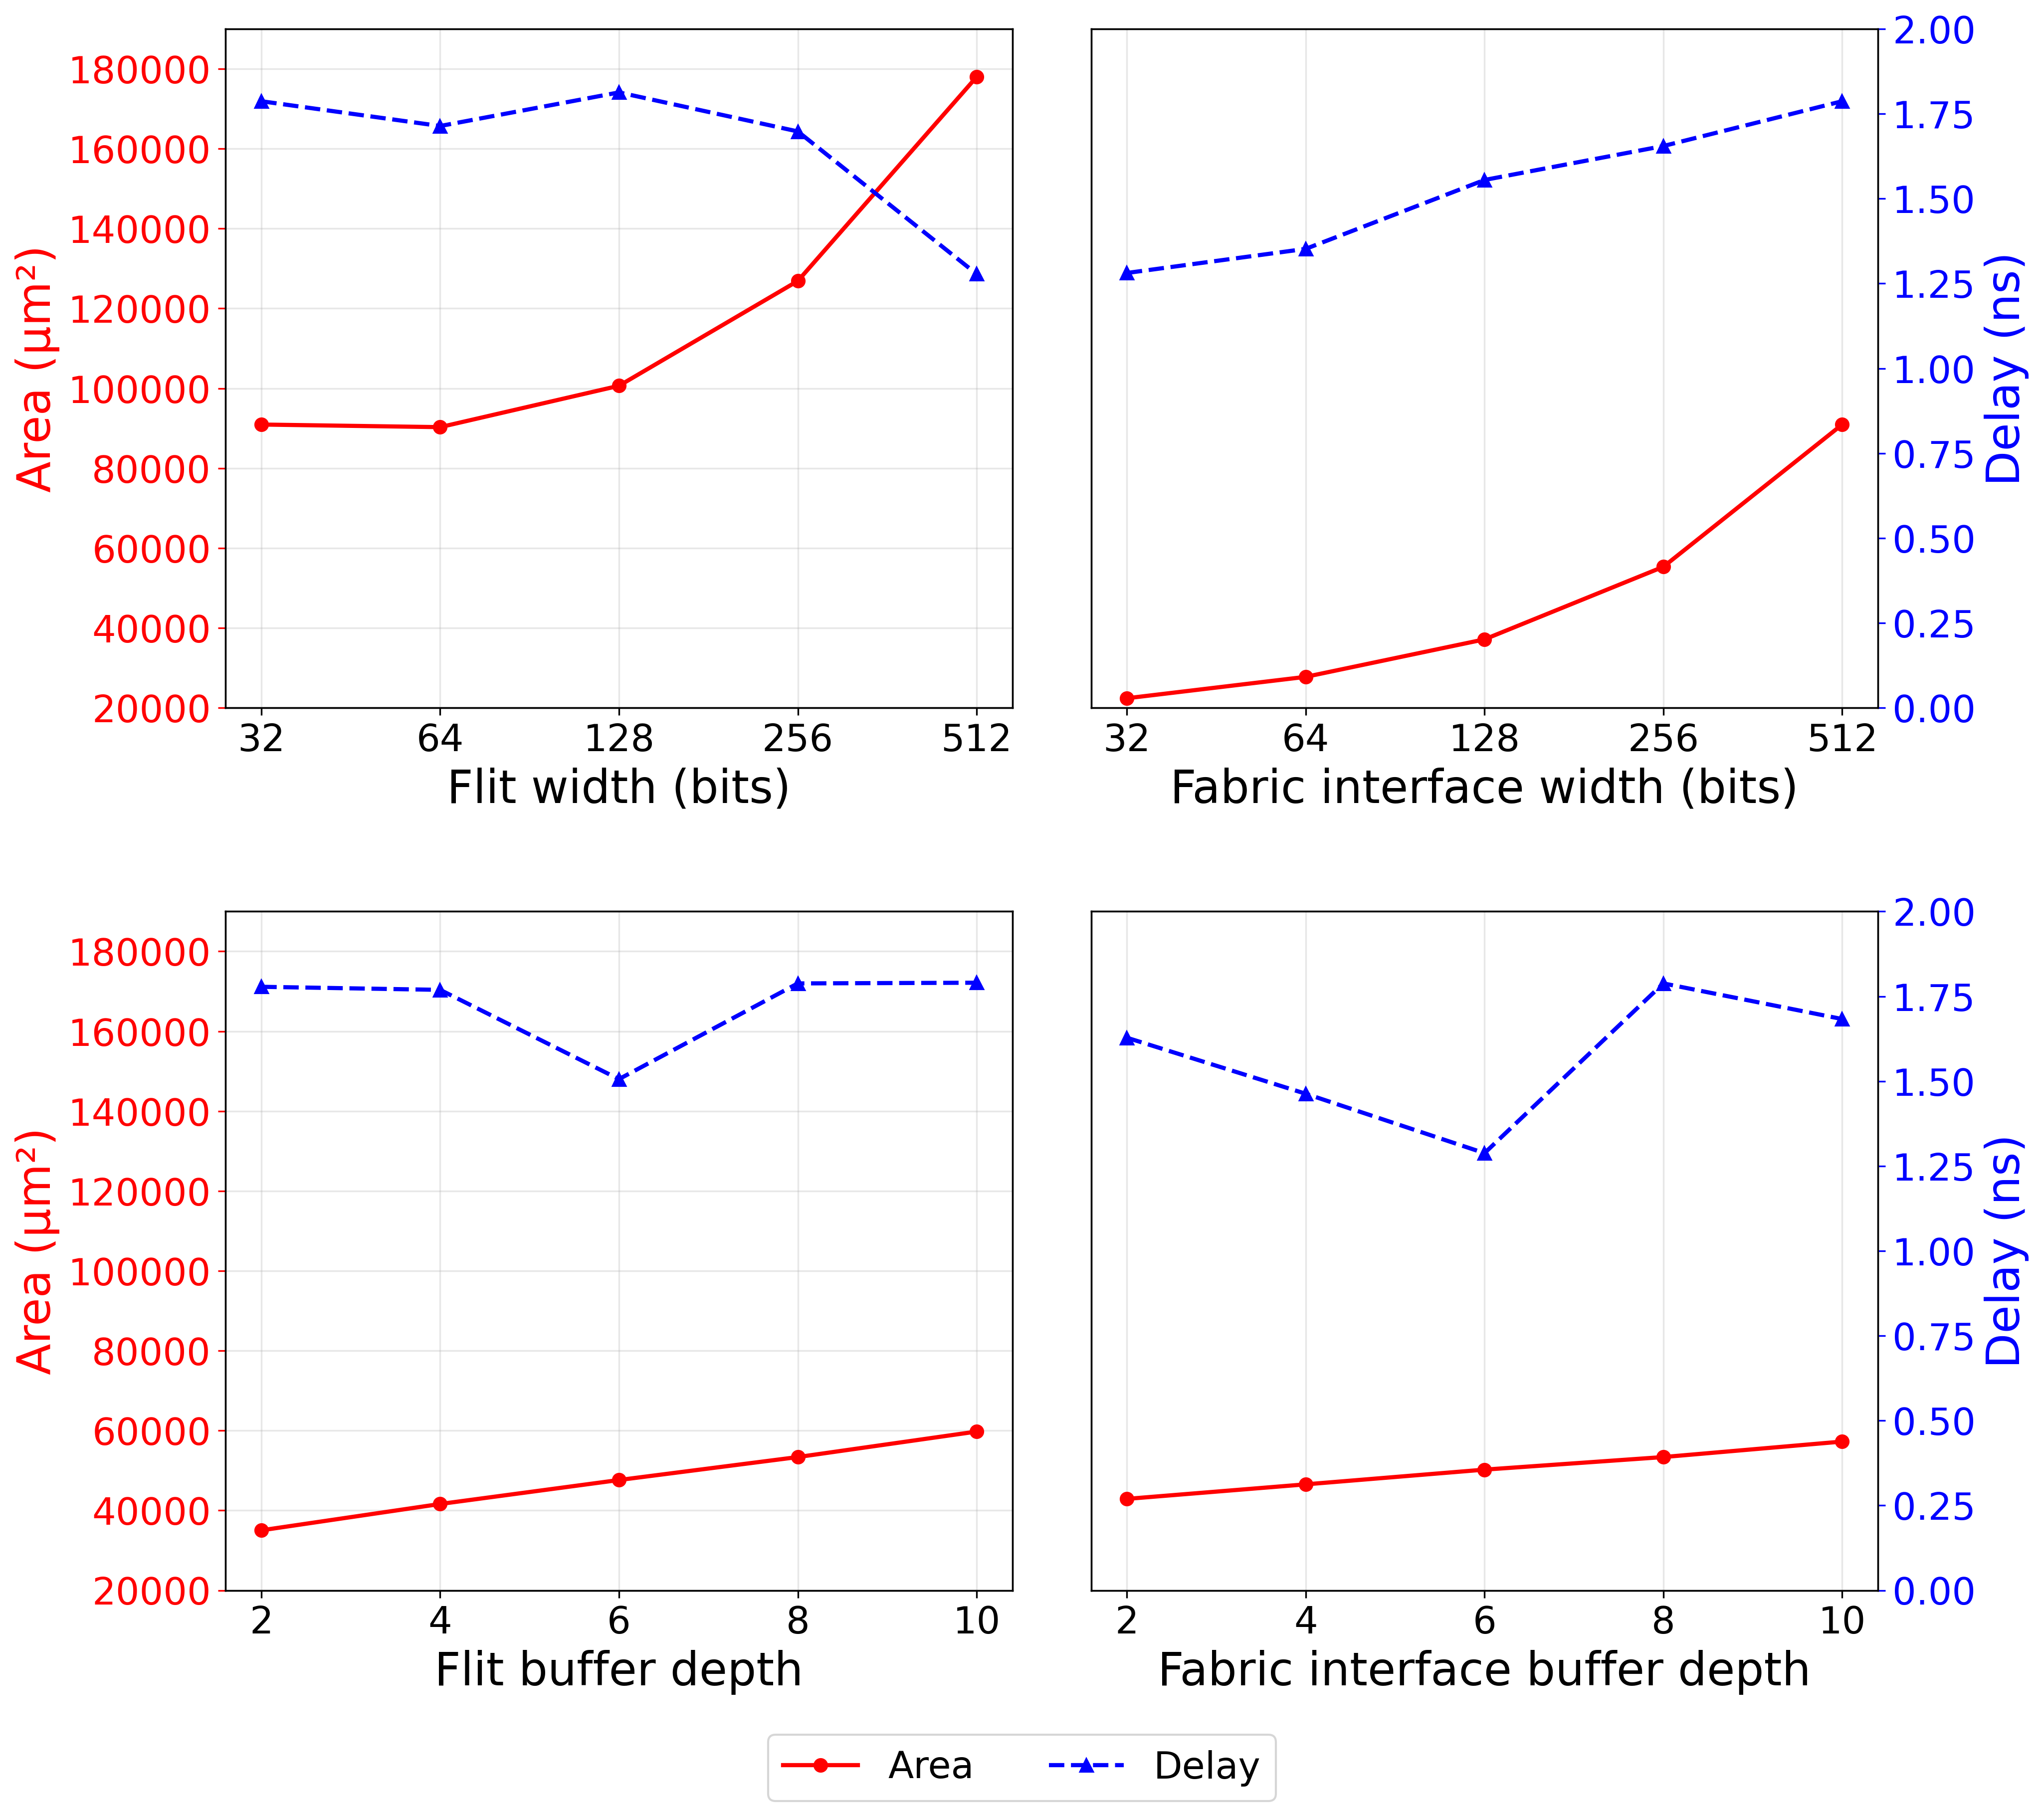

In [7]:
# Set up the figure with 2x2 subplots in a grid
fig, axs = plt.subplots(2, 2, figsize=(14, 12), dpi=300)
axs = axs.flatten()  # Flatten for easier indexing

# Common style parameters
area_style = {'color': 'r', 'marker': 'o', 'linestyle': '-', 'linewidth': 2, 'label': 'Area'}
delay_style = {'color': 'b', 'marker': '^', 'linestyle': '--', 'linewidth': 2, 'label': 'Delay'}

depths = [2, 4, 6, 8, 10]

# =============== PLOT 1: FLIT WIDTH IMPACT ===============
flit_widths = [32, 64, 128, 256, 512]
flit_areas = [90932.1, 90281.464, 100634.184, 126885.192, 177986.718]
flit_delays = [1.787, 1.714, 1.813, 1.698, 1.278]

ax1 = axs[0]
ax1_2 = ax1.twinx()

# Plot area on left y-axis
ax1.plot(depths, flit_areas, **area_style)
ax1.set_xlabel('Flit width (bits)', fontsize=22)
ax1.set_xticks(depths)
ax1.set_xticklabels(flit_widths)  # Set x-ticks to flit widths

ax1.set_ylabel('Area (μm²)', color='r', fontsize=22)
ax1.tick_params(axis='y', colors='r')
ax1.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax1_2.plot(depths, flit_delays, **delay_style)
# ax1_2.set_ylabel('Delay (ns)', color='b', fontsize=22)  # Added ylabel
# ax1_2.tick_params(axis='y', colors='b')
ax1_2.set_yticks([])  # Removed y-ticks for cleaner look
ax1_2.set_ylim(0, 2.0)
# Removed: ax1_2.yaxis.set_ticks([])

ax1.grid(True, alpha=0.3)

# =============== PLOT 2: INTERFACE WIDTH IMPACT ===============
interface_widths = [32, 64, 128, 256, 512]
interface_areas = [22387.624, 27746.992, 37134.398, 55305.39, 90932.1]
interface_delays = [1.281, 1.352, 1.555, 1.655, 1.787]

ax2 = axs[1]
ax2_2 = ax2.twinx()

# Plot area on left y-axis
ax2.plot(depths, interface_areas, **area_style)
ax2.set_xlabel('Fabric interface width (bits)', fontsize=22)
ax2.set_xticks(depths)
ax2.set_xticklabels(interface_widths)  # Set x-ticks to interface widths 
ax2.yaxis.set_ticks([]) 
ax2.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax2_2.plot(depths, interface_delays, **delay_style)
ax2_2.set_ylabel('Delay (ns)', color='b', fontsize=22)  # Added ylabel
ax2_2.tick_params(axis='y', colors='b')
ax2_2.set_ylim(0, 2.0)
# Removed: ax2_2.yaxis.set_ticks([])

ax2.grid(True, alpha=0.3)

# =============== PLOT 3: FLIT BUFFER DEPTH IMPACT ===============
depths = [2, 4, 6, 8, 10]
flit_buf_areas = [35024.22, 41617.03, 47620.65, 53370.24, 59752.644]
flit_buf_delays = [1.778, 1.769, 1.506, 1.788, 1.79]

ax3 = axs[2]
ax3_2 = ax3.twinx()

# Plot area on left y-axis
ax3.plot(depths, flit_buf_areas, **area_style)
ax3.set_xlabel('Flit buffer depth', fontsize=22)
ax3.set_ylabel('Area (μm²)', color='r', fontsize=22)
ax3.tick_params(axis='y', colors='r')
ax3.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax3_2.plot(depths, flit_buf_delays, **delay_style)
ax3_2.yaxis.set_ticks([])
ax3_2.set_ylim(0, 2.0)

ax3.grid(True, alpha=0.3)

# =============== PLOT 4: INTERFACE BUFFER DEPTH IMPACT ===============
if_buf_areas = [42894.894, 46535.104, 50220.8, 53370.24, 57248.52]
if_buf_delays = [1.628, 1.463, 1.288, 1.788, 1.683]

ax4 = axs[3]
ax4_2 = ax4.twinx()

# Plot area on left y-axis
ax4.plot(depths, if_buf_areas, **area_style)
ax4.set_xlabel('Fabric interface buffer depth', fontsize=22)
ax4.yaxis.set_ticks([]) 
ax4.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax4_2.plot(depths, if_buf_delays, **delay_style)
ax4_2.set_ylabel('Delay (ns)', color='b', fontsize=22)
ax4_2.tick_params(axis='y', colors='b')
ax4_2.set_ylim(0, 2.0)

ax4.grid(True, alpha=0.3)

# Create a shared legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.03))

plt.tight_layout()

plt.rcParams.update({'font.size': 18})

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=18)

twin_axes = [ax1_2, ax2_2, ax3_2, ax4_2]
for ax in twin_axes:
    ax.tick_params(axis='y', which='major', labelsize=18)
    
plt.subplots_adjust(bottom=0.1, wspace=0.1, hspace=0.3)  # Adjust spacing for 2x2 layout
plt.savefig('noc_design_parameters_2x2.png', bbox_inches='tight')
plt.show()

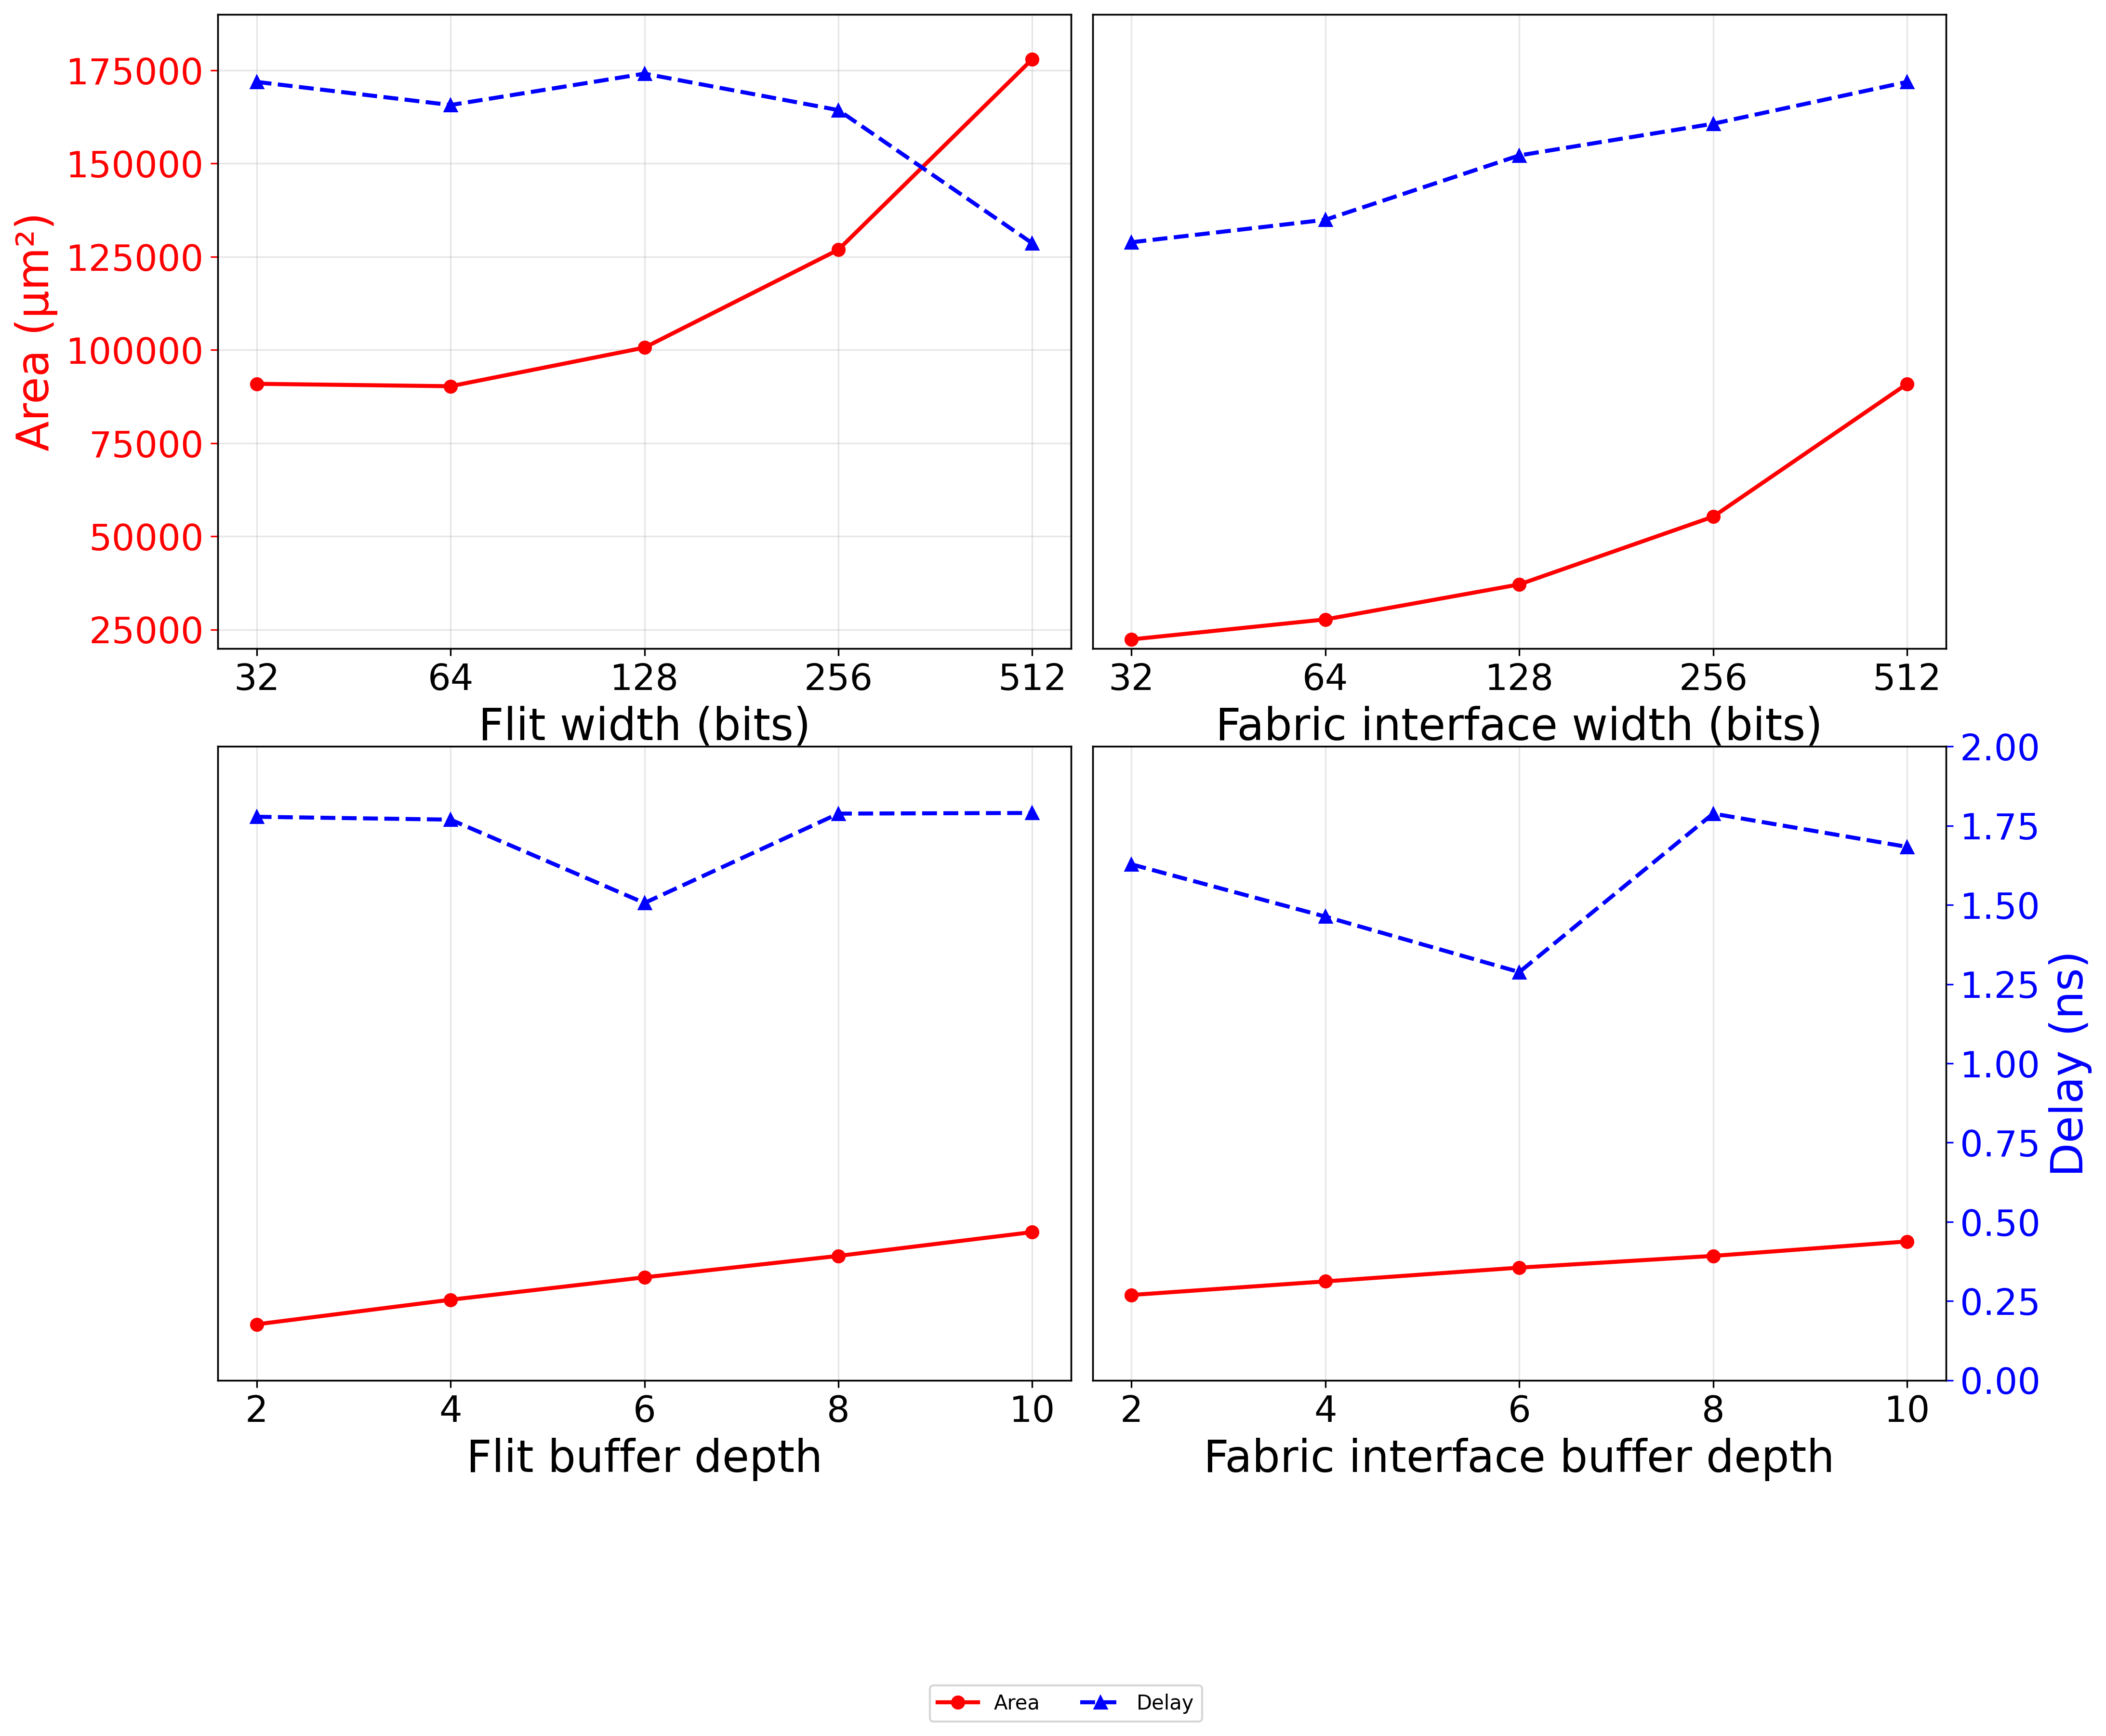

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Set up the figure with four subplots in a row
fig, axs = plt.subplots(2, 2, figsize=(14, 12), dpi=300)
axs = axs.flatten() 
# Common style parameters
area_style = {'color': 'r', 'marker': 'o', 'linestyle': '-', 'linewidth': 2, 'label': 'Area'}
delay_style = {'color': 'b', 'marker': '^', 'linestyle': '--', 'linewidth': 2, 'label': 'Delay'}

depths = [2, 4, 6, 8, 10]

# =============== PLOT 1: FLIT WIDTH IMPACT ===============
flit_widths = [32, 64, 128, 256, 512]
flit_areas = [90932.1, 90281.464, 100634.184, 126885.192, 177986.718]
flit_delays = [1.787, 1.714, 1.813, 1.698, 1.278]

ax1 = axs[0]
ax1_2 = ax1.twinx()

# Plot area on left y-axis
ax1.plot(depths, flit_areas, **area_style)
ax1.set_xlabel('Flit width (bits)', fontsize=22)
ax1.set_xticks(depths)
ax1.set_xticklabels(flit_widths)  # Set x-ticks to flit widths

ax1.set_ylabel('Area (μm²)', color='r', fontsize=22)
ax1.tick_params(axis='y', colors='r')
ax1.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax1_2.plot(depths, flit_delays, **delay_style)

# ax1_2.set_ylim(1.0, 2.0)
ax1_2.set_ylim(0, 2.0)
ax1_2.yaxis.set_ticks([]) 


# ax1.set_title('Flit Width Impact', fontsize=11)
ax1.grid(True, alpha=0.3)

# =============== PLOT 2: INTERFACE WIDTH IMPACT ===============
interface_widths = [32, 64, 128, 256, 512]
interface_areas = [22387.624, 27746.992, 37134.398, 55305.39, 90932.1]
interface_delays = [1.281, 1.352, 1.555, 1.655, 1.787]

ax2 = axs[1]
ax2_2 = ax2.twinx()

# Plot area on left y-axis
ax2.plot(depths, interface_areas, **area_style)
ax2.set_xlabel('Fabric interface width (bits)', fontsize=22)
ax2.set_xticks(depths)
ax2.set_xticklabels(interface_widths)  # Set x-ticks to interface widths 
ax2.yaxis.set_ticks([]) 
ax2.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax2_2.plot(depths, interface_delays, **delay_style)
ax2_2.yaxis.set_ticks([])
# ax2_2.set_ylim(1.0, 2.0)
ax2_2.set_ylim(0, 2.0)


ax2.grid(True, alpha=0.3)

# =============== PLOT 3: FLIT BUFFER DEPTH IMPACT ===============
depths = [2, 4, 6, 8, 10]
flit_buf_areas = [35024.22, 41617.03, 47620.65, 53370.24, 59752.644]
flit_buf_delays = [1.778, 1.769, 1.506, 1.788, 1.79]

ax3 = axs[2]
ax3_2 = ax3.twinx()

# Plot area on left y-axis
ax3.plot(depths, flit_buf_areas, **area_style)
ax3.set_xlabel('Flit buffer depth', fontsize=22)
ax3.yaxis.set_ticks([])
ax3.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax3_2.plot(depths, flit_buf_delays, **delay_style)
ax3_2.yaxis.set_ticks([])
# ax3_2.set_ylim(1.0, 2.0)
ax3_2.set_ylim(0, 2.0)

ax3.grid(True, alpha=0.3)

# =============== PLOT 4: INTERFACE BUFFER DEPTH IMPACT ===============
if_buf_areas = [42894.894, 46535.104, 50220.8, 53370.24, 57248.52]
if_buf_delays = [1.628, 1.463, 1.288, 1.788, 1.683]

ax4 = axs[3]
ax4_2 = ax4.twinx()

# Plot area on left y-axis
ax4.plot(depths, if_buf_areas, **area_style)
ax4.set_xlabel('Fabric interface buffer depth', fontsize=22)
ax4.yaxis.set_ticks([])
ax4.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax4_2.plot(depths, if_buf_delays, **delay_style)
ax4_2.set_ylabel('Delay (ns)', color='b', fontsize=22)
ax4_2.tick_params(axis='y', colors='b')
# ax4_2.set_ylim(1.0, 2.0)
ax4_2.set_ylim(0, 2.0)

ax4.grid(True, alpha=0.3)

# Create a shared legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.03))

plt.tight_layout()

plt.rcParams.update({'font.size': 18})

# # Set specific element font sizes
# plt.rcParams.update({
#     'axes.titlesize': 14,     # Plot titles
#     'axes.labelsize': 18,     # Axis labels
#     'xtick.labelsize': 16,    # X-axis tick labels
#     'ytick.labelsize': 16,    # Y-axis tick labels
#     'legend.fontsize': 16,    # Legend text
# })

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=18)
    if hasattr(ax, 'right_ax'):
        ax.right_ax.tick_params(axis='both', which='major', labelsize=18)
for ax in [ax1_2, ax2_2, ax3_2, ax4_2]:
    ax.tick_params(axis='y', which='major', labelsize=18)
plt.subplots_adjust(bottom=0.2)  # Make room for the legend at the bottom
plt.savefig('noc_design_parameters.png', bbox_inches='tight')
plt.show()

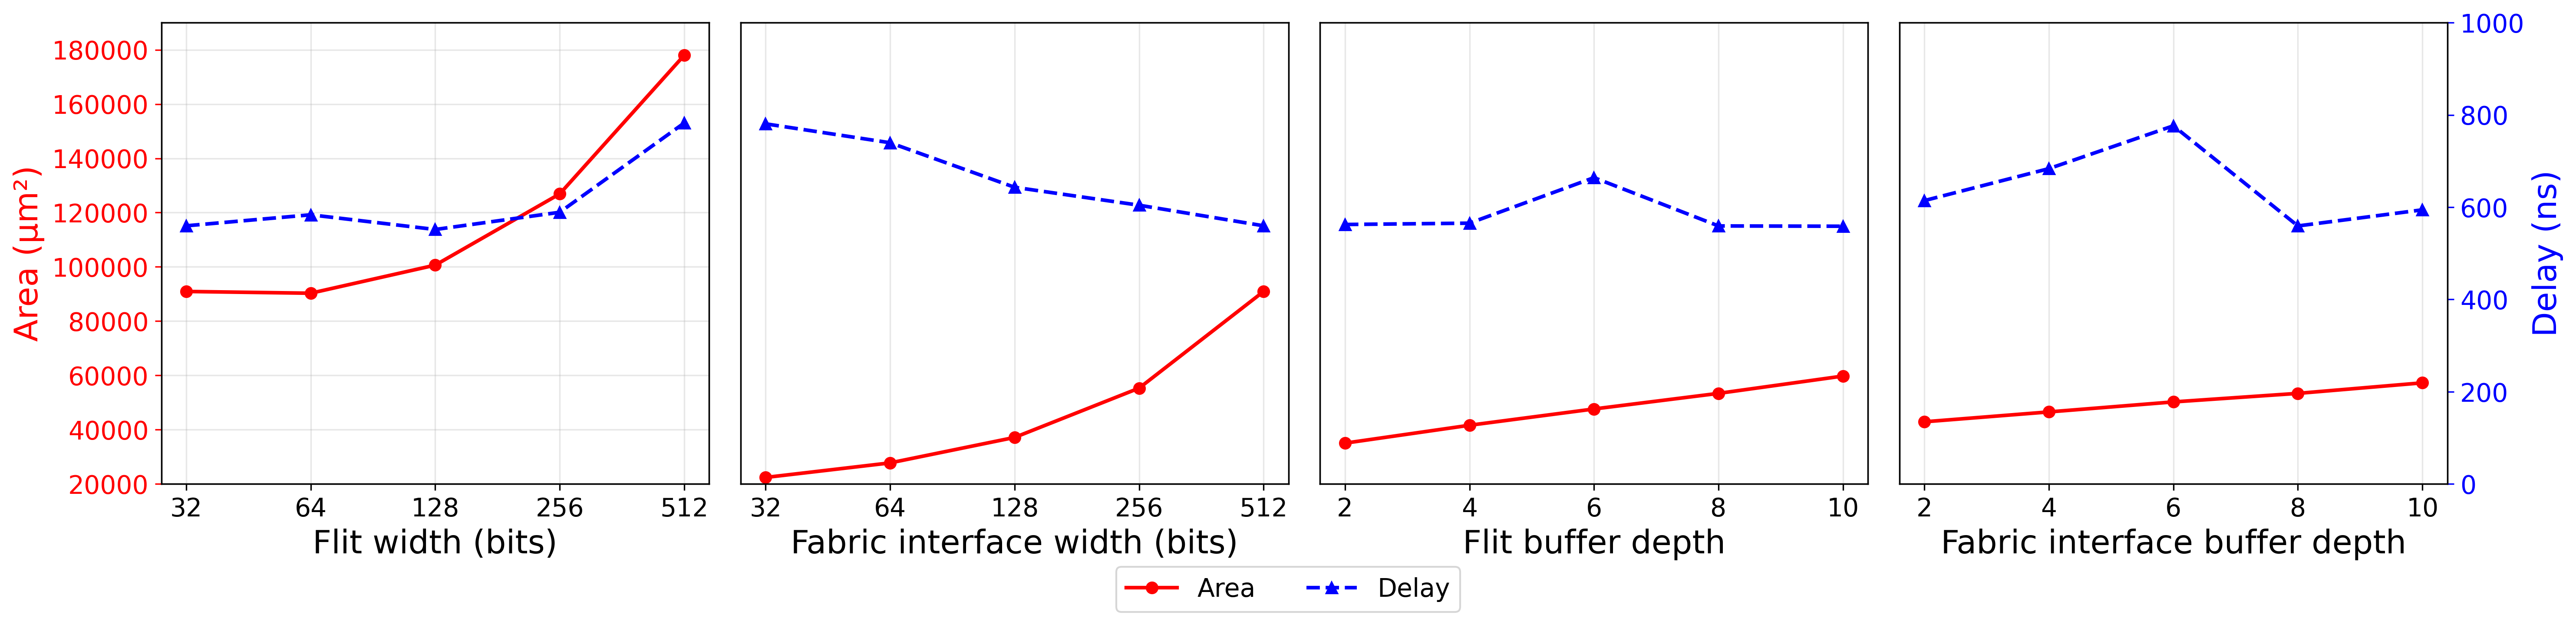

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Set up the figure with four subplots in a row
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5), dpi=300)

# Common style parameters
area_style = {'color': 'r', 'marker': 'o', 'linestyle': '-', 'linewidth': 2, 'label': 'Area'}
delay_style = {'color': 'b', 'marker': '^', 'linestyle': '--', 'linewidth': 2, 'label': 'Delay'}

depths = [2, 4, 6, 8, 10]

# =============== PLOT 1: FLIT WIDTH IMPACT ===============
flit_widths = [32, 64, 128, 256, 512]
flit_areas = [90932.1, 90281.464, 100634.184, 126885.192, 177986.718]
flit_delays = [1.787, 1.714, 1.813, 1.698, 1.278]

#  invert delays (1 div delay)
flit_delays = [1000 / delay for delay in flit_delays]
# flit_delays = [1000* delay for delay in flit_delays]  # Convert to ns

ax1 = axs[0]
ax1_2 = ax1.twinx()

# Plot area on left y-axis
ax1.plot(depths, flit_areas, **area_style)
ax1.set_xlabel('Flit width (bits)', fontsize=18)
ax1.set_xticks(depths)
ax1.set_xticklabels(flit_widths)  # Set x-ticks to flit widths

ax1.set_ylabel('Area (μm²)', color='r', fontsize=18)
ax1.tick_params(axis='y', colors='r')
ax1.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax1_2.plot(depths, flit_delays, **delay_style)

# ax1_2.set_ylim(1.0, 2.0)
ax1_2.set_ylim(0, 1000)
ax1_2.yaxis.set_ticks([]) 


# ax1.set_title('Flit Width Impact', fontsize=11)
ax1.grid(True, alpha=0.3)

# =============== PLOT 2: INTERFACE WIDTH IMPACT ===============
interface_widths = [32, 64, 128, 256, 512]
interface_areas = [22387.624, 27746.992, 37134.398, 55305.39, 90932.1]
interface_delays = [1.281, 1.352, 1.555, 1.655, 1.787]

interface_delays = [1000 / delay for delay in interface_delays]

ax2 = axs[1]
ax2_2 = ax2.twinx()

# Plot area on left y-axis
ax2.plot(depths, interface_areas, **area_style)
ax2.set_xlabel('Fabric interface width (bits)', fontsize=18)
ax2.set_xticks(depths)
ax2.set_xticklabels(interface_widths)  # Set x-ticks to interface widths 
ax2.yaxis.set_ticks([]) 
ax2.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax2_2.plot(depths, interface_delays, **delay_style)
ax2_2.yaxis.set_ticks([])
# ax2_2.set_ylim(1.0, 2.0)
ax2_2.set_ylim(0, 1000)


ax2.grid(True, alpha=0.3)

# =============== PLOT 3: FLIT BUFFER DEPTH IMPACT ===============
depths = [2, 4, 6, 8, 10]
flit_buf_areas = [35024.22, 41617.03, 47620.65, 53370.24, 59752.644]
flit_buf_delays = [1.778, 1.769, 1.506, 1.788, 1.79]

# Invert delays (1 div delay)
flit_buf_delays = [1000 / delay for delay in flit_buf_delays]

ax3 = axs[2]
ax3_2 = ax3.twinx()

# Plot area on left y-axis
ax3.plot(depths, flit_buf_areas, **area_style)
ax3.set_xlabel('Flit buffer depth', fontsize=18)
ax3.yaxis.set_ticks([])
ax3.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax3_2.plot(depths, flit_buf_delays, **delay_style)
ax3_2.yaxis.set_ticks([])
# ax3_2.set_ylim(1.0, 2.0)
ax3_2.set_ylim(0, 1000)

ax3.grid(True, alpha=0.3)

# =============== PLOT 4: INTERFACE BUFFER DEPTH IMPACT ===============
if_buf_areas = [42894.894, 46535.104, 50220.8, 53370.24, 57248.52]
if_buf_delays = [1.628, 1.463, 1.288, 1.788, 1.683]

# invert delays (1 div delay)
if_buf_delays = [1000 / delay for delay in if_buf_delays]

ax4 = axs[3]
ax4_2 = ax4.twinx()

# Plot area on left y-axis
ax4.plot(depths, if_buf_areas, **area_style)
ax4.set_xlabel('Fabric interface buffer depth', fontsize=18)
ax4.yaxis.set_ticks([])
ax4.set_ylim(20000, 190000)

# Plot delay on right y-axis
ax4_2.plot(depths, if_buf_delays, **delay_style)
ax4_2.set_ylabel('Delay (ns)', color='b', fontsize=18)
ax4_2.tick_params(axis='y', colors='b')
# ax4_2.set_ylim(1.0, 2.0)
# ax4_2.set_yticks())
ax4_2.set_ylim(0, 1000)

ax4.grid(True, alpha=0.3)

# Create a shared legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.03))

plt.tight_layout()

plt.rcParams.update({'font.size': 14})

# # Set specific element font sizes
# plt.rcParams.update({
#     'axes.titlesize': 14,     # Plot titles
#     'axes.labelsize': 18,     # Axis labels
#     'xtick.labelsize': 16,    # X-axis tick labels
#     'ytick.labelsize': 16,    # Y-axis tick labels
#     'legend.fontsize': 16,    # Legend text
# })

plt.subplots_adjust(bottom=0.15)  # Make room for the legend at the bottom
plt.savefig('noc_design_parameters.png', bbox_inches='tight')
plt.show()